# Notebook \#9 Compare my catalog with MUSE catalog

In [41]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame, search_around_sky
from scipy.stats import linregress
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
import os
import re
import matplotlib as mpl
import seaborn as sns
from astroquery.vizier import Vizier



plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

#add rc param for ticks are inwards and minor ticks are on
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)



In [42]:
# load in the SW field map

sw_map_path = '../M33-Maps-Calibrated/M33-SW/M33SW-Haflux.fits'
sw_map_hdu = fits.open(sw_map_path)[0]
sw_map_data = sw_map_hdu.data
sw_map_wcs = WCS(sw_map_hdu.header)

peaks_path = "CATALOGS/final_peaks_SW.csv"
central_peaks_df = pd.read_csv(peaks_path)

cat = pd.read_csv("CATALOGS/flux_catalogs/total_flux_catalog_with_deprojected_clustering_metrics.csv")
#limit cat to just the SW field
cat = cat[cat["field"] == "SW"].reset_index(drop=True)

wcs = WCS(sw_map_hdu.header)

In [43]:
#load in the MUSE catalog from Vizier
catalog_id = "J/A+A/706/A367/catalog"

v = Vizier(columns=["all"], row_limit=-1)
tables = v.get_catalogs(catalog_id)

muse = tables[0].to_pandas()

muse = muse.rename(columns={
    "RAJ2000": "RA",
    "DEJ2000": "Dec",
    "E(B-V)": "EBV",
    "(O/H)N2S2Ha": "OH_N2S2Ha",
    "(O/H)S": "OH_Scal",
})

# force numeric for the columns you’ll use
cols_to_numeric = [
    "RA", "Dec", "EBV", "ne", "metallicity",
    "FHb", "FHa6562", "FOIII5006", "FNII6583", "FSII6716", "FSII6730",
    "e_FHb", "e_FHa6562", "e_FOIII5006", "e_FNII6583", "e_FSII6716", "e_FSII6730",
]
for col in cols_to_numeric:
    if col in muse.columns:
        muse[col] = pd.to_numeric(muse[col], errors="coerce")

muse = muse.dropna(subset=["RA", "Dec"]).reset_index(drop=True)

print(muse.columns)

print("number of rows in full MUSE catalog:", len(muse))

Index(['recno', 'ID', 'RA', 'Dec', 'Npix', 'Star', 'YSCC', 'EBV', 'ne',
       'OH_Scal', 'OH_N2S2Ha', 'FHb', 'FOIII4958', 'FOIII5006', 'FHeI5015',
       'FNII5754', 'FHeI5875', 'FNII6548', 'FHa6562', 'FNII6583', 'FHeI6678',
       'FSII6716', 'FSII6730', 'FHeI7065', 'FArIII7135', 'FOII7325',
       'FArIII7751', 'FHPa128750', 'FHPa118862', 'FHPa109015', 'FSIII9068',
       'FHPa99229', 'e_FHb', 'e_FOIII4958', 'e_FOIII5006', 'e_FHeI5015',
       'e_FNII5754', 'e_FHeI5875', 'e_FNII6548', 'e_FHa6562', 'e_FNII6583',
       'e_FHeI6678', 'e_FSII6716', 'e_FSII6730', 'e_FHeI7065', 'e_FArIII7135',
       'e_FOII7325', 'e_FArIII7751', 'e_FHPa128750', 'e_FHPa118862',
       'e_FHPa109015', 'e_FSIII9068', 'e_FHPa99229'],
      dtype='object')
number of rows in full MUSE catalog: 131


In [44]:
muse

,recno,ID,RA,Dec,Npix,Star,YSCC,EBV,ne,OH_Scal,...,e_FSII6730,e_FHeI7065,e_FArIII7135,e_FOII7325,e_FArIII7751,e_FHPa128750,e_FHPa118862,e_FHPa109015,e_FSIII9068,e_FHPa99229
0,1,1,23.398001,30.500000,618,,<NA>,0.055,20.0,8.289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,23.403000,30.502001,767,,<NA>,0.104,20.0,8.292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,3,23.403000,30.504999,569,,<NA>,0.160,20.0,8.270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,4,23.386999,30.527000,3648,,<NA>,0.164,20.0,8.304,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,5,23.419001,30.517000,1558,,<NA>,0.059,20.0,8.338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,127,148,23.452999,30.625000,1388,,<NA>,0.157,20.0,8.384,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,128,149,23.458000,30.625999,4405,,201,0.213,20.0,8.482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,129,151,23.469999,30.629000,915,,718,0.206,20.0,8.402,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,130,152,23.459999,30.631001,517,,<NA>,0.097,20.0,8.392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:

def label_edges(label_map):
    lab = np.asarray(label_map)
    valid = np.isfinite(lab) & (lab > 0)

    edges = np.zeros(lab.shape, dtype=bool)

    v1 = valid[:, :-1]
    v2 = valid[:, 1:]
    l1 = lab[:, :-1]
    l2 = lab[:, 1:]
    boundary_x = (v1 != v2) | (v1 & v2 & (l1 != l2))
    edges[:, :-1] |= boundary_x
    edges[:, 1:] |= boundary_x

    v1 = valid[:-1, :]
    v2 = valid[1:, :]
    l1 = lab[:-1, :]
    l2 = lab[1:, :]
    boundary_y = (v1 != v2) | (v1 & v2 & (l1 != l2))
    edges[:-1, :] |= boundary_y
    edges[1:, :] |= boundary_y

    return edges


muse_strip_centres = [
    ("1-3",   "01:33:44.273", "30:33:54.770"),
    ("4-6",   "01:33:45.956", "30:34:48.550"),
    ("7-9",   "01:33:47.638", "30:35:42.327"),
    ("10-12", "01:33:51.005", "30:37:29.879"),
    ("13-15", "01:33:42.591", "30:33:00.999"),
    ("16-18", "01:33:40.909", "30:32:07.221"),
    ("19-21", "01:33:39.230", "30:31:13.444"),
    ("22-24", "01:33:37.547", "30:30:19.667"),
]


def make_muse_pointing_centres(strip_centres, axis_pa_deg=22.0, spacing_arcsec=58.0):
    pointings = []
    cross_pa = (axis_pa_deg + 90.0) * u.deg

    for strip_label, ra_str, dec_str in strip_centres:
        c0 = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))

        for i, offset in enumerate([-spacing_arcsec, 0.0, spacing_arcsec], start=1):
            if offset == 0:
                c = c0
            else:
                c = c0.directional_offset_by(
                    cross_pa if offset > 0 else cross_pa + 180 * u.deg,
                    abs(offset) * u.arcsec
                )

            pointings.append({
                "strip": strip_label,
                "pointing_index_in_strip": i,
                "coord": c,
            })

    return pointings


def rotated_square_corners(center, size_arcsec=60.0, pa_deg=22.0):
    h = size_arcsec / 2.0
    theta = np.deg2rad(pa_deg)

    uv = np.array([
        [-h, -h],
        [ h, -h],
        [ h,  h],
        [-h,  h],
        [-h, -h],
    ], dtype=float)

    east  = uv[:, 0] * np.cos(theta) + uv[:, 1] * np.sin(theta)
    north = -uv[:, 0] * np.sin(theta) + uv[:, 1] * np.cos(theta)

    frame = SkyOffsetFrame(origin=center)
    corners_offset = SkyCoord(lon=east * u.arcsec, lat=north * u.arcsec, frame=frame)
    return corners_offset.transform_to("icrs")


def points_in_rotated_square(px, py, cx, cy, size_pix, pa_deg):
    dx = px - cx
    dy = py - cy

    theta = np.deg2rad(pa_deg)

    u1 = dx * np.cos(theta) + dy * np.sin(theta)
    v1 = -dx * np.sin(theta) + dy * np.cos(theta)

    half = size_pix / 2.0
    return (np.abs(u1) <= half) & (np.abs(v1) <= half)


def plot_sw_halpha_with_muse_footprint(
    ha_path,
    boundary_path,
    central_peaks,
    x_col="x",
    y_col="y",
    muse_axis_pa_deg=22.0,
    muse_spacing_arcsec=58.0,
    muse_fov_size_arcsec=60.0,
    sitelle_pixel_scale_arcsec=0.32,
    muse_square_pa_deg=22.0,
    figsize=(16, 16),
    xlim=(50, 2000),
    ylim=(50, 2000),
):
    # Load Halpha map + WCS
    with fits.open(ha_path) as hdul:
        ha_data = hdul[0].data
        wcs = WCS(hdul[0].header)

    boundary_map = fits.getdata(boundary_path)

    # Prepare log Halpha map
    ha_plot = np.array(ha_data, dtype=float)
    ha_plot[~np.isfinite(ha_plot) | (ha_plot <= 0)] = np.nan
    log_ha = np.log10(ha_plot)

    # Region boundaries
    edges = label_edges(boundary_map)

    # Peaks
    if isinstance(central_peaks, pd.DataFrame):
        x_peaks = central_peaks[x_col].to_numpy(dtype=float)
        y_peaks = central_peaks[y_col].to_numpy(dtype=float)
    else:
        central_peaks = np.asarray(central_peaks, dtype=float)
        x_peaks = central_peaks[:, 0]
        y_peaks = central_peaks[:, 1]

    # Build the 24 MUSE pointing centers
    muse_pointings = make_muse_pointing_centres(
        muse_strip_centres,
        axis_pa_deg=muse_axis_pa_deg,
        spacing_arcsec=muse_spacing_arcsec,
    )

    # Convert MUSE centers to SITELLE pixels
    muse_centers_world = SkyCoord([p["coord"] for p in muse_pointings])
    muse_x, muse_y = wcs.world_to_pixel(muse_centers_world)

    # MUSE FoV size in SITELLE pixels
    muse_size_pix = muse_fov_size_arcsec / sitelle_pixel_scale_arcsec

    # Count peaks inside any MUSE pointing
    inside_any_muse = np.zeros(len(x_peaks), dtype=bool)
    for cx, cy in zip(muse_x, muse_y):
        inside_any_muse |= points_in_rotated_square(
            x_peaks, y_peaks, cx, cy,
            size_pix=muse_size_pix,
            pa_deg=muse_square_pa_deg,
        )
    n_peaks_in_muse = int(np.sum(inside_any_muse))

    # Plot
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection=wcs)

    im = ax.imshow(
        log_ha,
        origin="lower",
        cmap="rainbow",
        vmin=-18,
        vmax=-15,
    )

    # Region boundaries
    ax.contour(edges, levels=[0.5], colors="navy", linewidths=1.0)

    # # Peaks
    # ax.scatter(
    #     x_peaks,
    #     y_peaks,
    #     c="black",
    #     marker="x",
    #     s=28,
    #     linewidths=1.0,
    #     zorder=5,
    # )

    # MUSE footprint
    for p in muse_pointings:
        corners = rotated_square_corners(
            p["coord"],
            size_arcsec=muse_fov_size_arcsec,
            pa_deg=muse_square_pa_deg,
        )

        ax.plot(
            corners.ra.deg,
            corners.dec.deg,
            color="maroon",
            linewidth=3.2,
            transform=ax.get_transform("world"),
            zorder=6,
        )

    # Limits
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    
    # # convert to SkyCoord
    # muse_coords = SkyCoord(
    #     ra=muse["RA"].values * u.deg,
    #     dec=muse["Dec"].values * u.deg
    # )

    # # convert to SITELLE pixels
    # mx, my = wcs.world_to_pixel(muse_coords)

    # # plot as circles
    # ax.scatter(
    #     mx, my,
    #     s=80,                 # size of circles
    #     facecolors="none",
    #     edgecolors="cyan",    # or any color you like
    #     linewidths=1.5,
    #     zorder=8,
    #     label="MUSE regions"
    # )

    # Labels inside plot
    ax.text(
        0.97, 0.97, "SW SITELLE field",
        transform=ax.transAxes,
        ha="right", va="top",
        color="black",
        fontsize=28,
        bbox=dict(facecolor="white", edgecolor="k", alpha=0.8, pad=4),
        zorder=10,
    )

    ax.text(
        0.48, 0.18, "MUSE pointings",
        transform=ax.transAxes,
        ha="center",
        va="center",
        color="maroon",
        fontsize=30,
        rotation=22,
        bbox=dict(facecolor="white", edgecolor="maroon", alpha=0.85, pad=4),
        zorder=10,
    )

    # Axis labels and tick labels
    ax.coords[0].set_axislabel("RA", size=28)
    ax.coords[1].set_axislabel("Dec", size=28)
    ax.coords[0].set_ticklabel(size=22)
    ax.coords[1].set_ticklabel(size=22)

    # Keep ticks pointing inward, make them longer, add minor ticks
    ax.coords[0].display_minor_ticks(True)
    ax.coords[1].display_minor_ticks(True)
    ax.coords[0].set_ticks(size=12, width=1.8, direction='in')
    ax.coords[1].set_ticks(size=12, width=1.8, direction='in')
    ax.coords[0].set_minor_frequency(5)
    ax.coords[1].set_minor_frequency(5)
    

    # Colorbar sized to match map better
    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(
        r'log$_{10}$(H$\alpha$ flux [erg s$^{-1}$ cm$^{-2}$])',
        fontsize=24
    )
    cbar.ax.tick_params(labelsize=20, length=8, width=1.5)

    plt.tight_layout()
    plt.savefig("PAPER_PLOTS/M33_SW_with_MUSE_footprint.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Number of emission peaks inside the MUSE footprint: {n_peaks_in_muse}")

    return fig, ax, n_peaks_in_muse

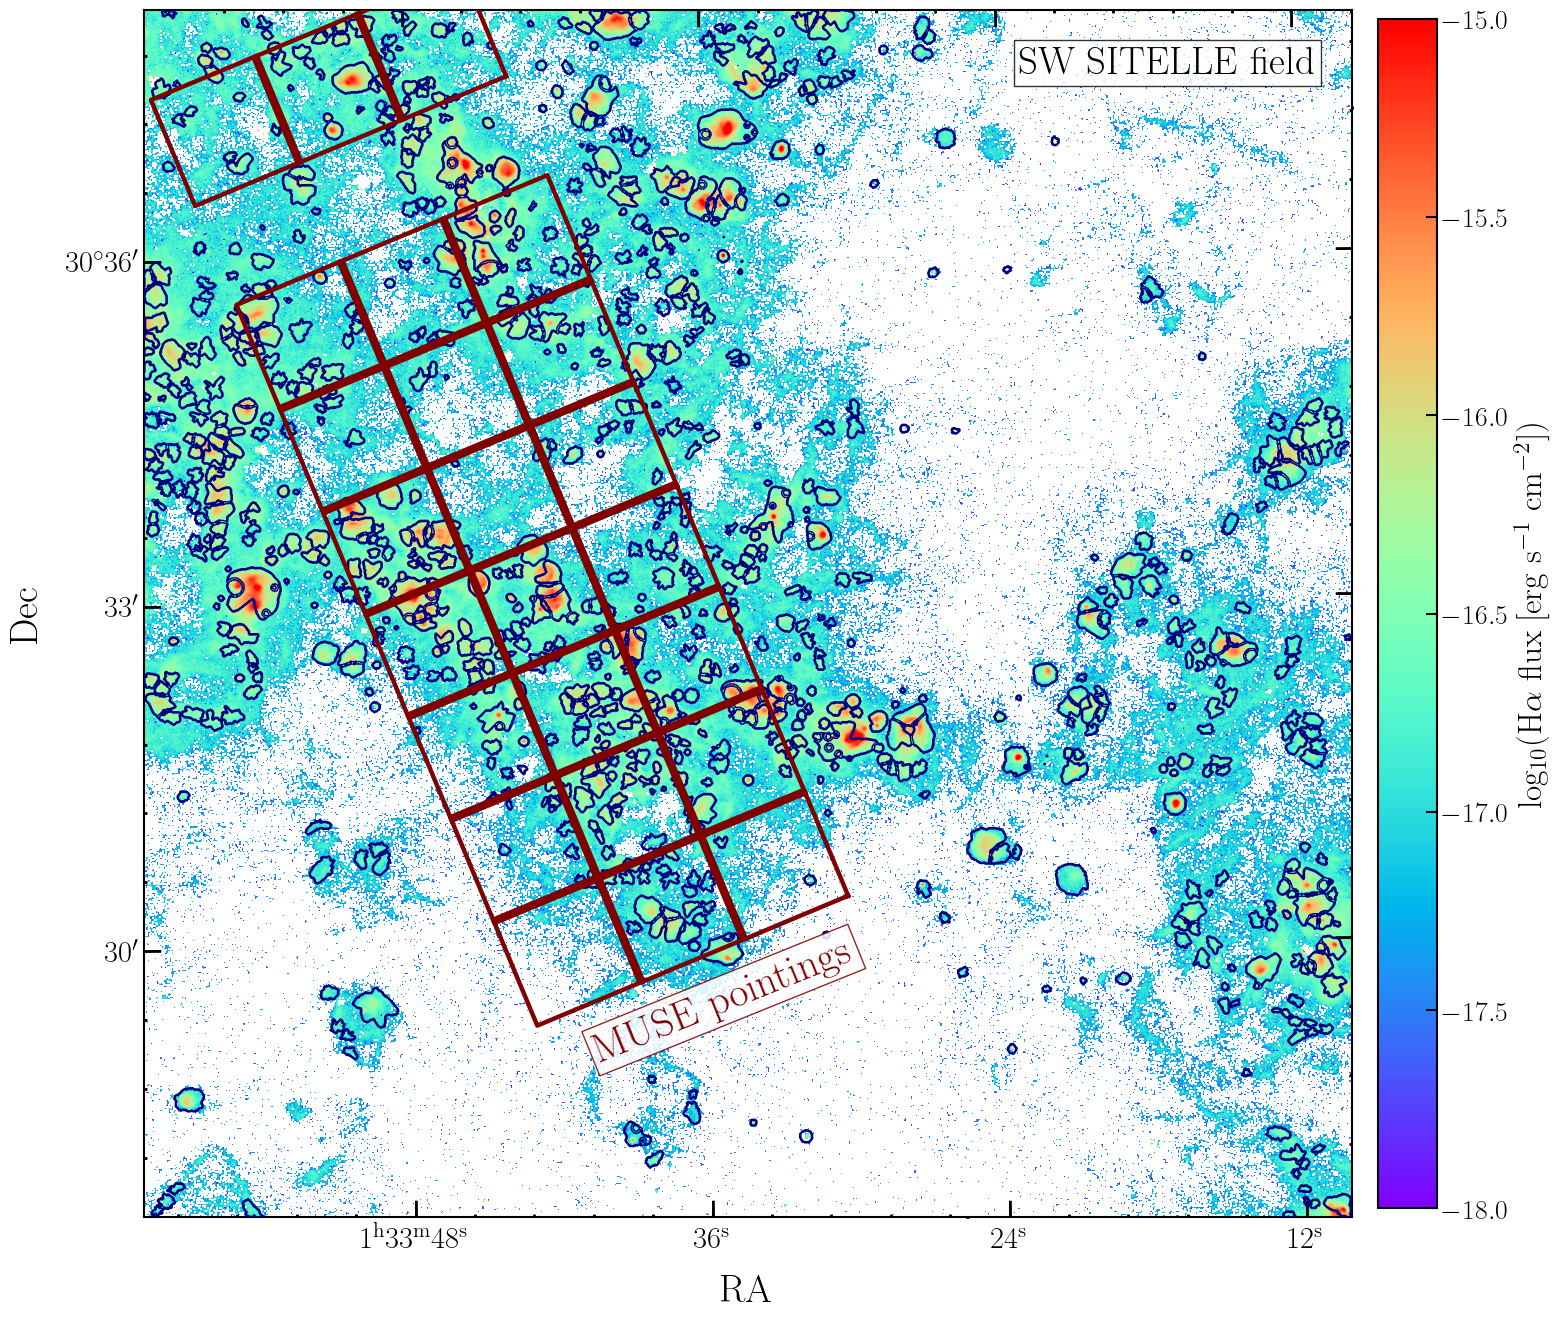

Number of emission peaks inside the MUSE footprint: 385


In [46]:
#plot the SW Halpha map with MUSE footprint and peaks

ha_path = '../M33-Maps-Calibrated/M33-SW/M33SW-Haflux.fits'
boundary_path = "Boundary_maps/Boundary_map_100pc/Boundary_map_SW.fits"

# Example: if central_peaks is a DataFrame with columns x and y
fig, ax, n_peaks_in_muse = plot_sw_halpha_with_muse_footprint(
    ha_path=ha_path,
    boundary_path=boundary_path,
    central_peaks=central_peaks_df
)

In [47]:
from pathlib import Path

#add this number to the latex file for the paper

filename = Path("catalog_numbers.tex")

line = f"\\newcommand{{\\nPeaksMUSE}}{{{n_peaks_in_muse}}}\n"

if filename.exists():
    content = filename.read_text()
    if "\\nPeaksMUSE" not in content:
        with open(filename, "a") as f:
            f.write(line)
            print(f"Appended number of peaks in MUSE footprint to {filename}")
else:
    with open(filename, "w") as f:
        f.write(line)
        print(f"Created {filename} with number of peaks in MUSE footprint")

Appended number of peaks in MUSE footprint to catalog_numbers.tex


In [48]:
# Now we have a function to get the subset of the catalog that is inside the MUSE footprint, along with boolean masks and indices for later use in cross-matching.

def get_regions_in_muse_footprint(
    region_catalog,
    wcs,
    muse_pointings,
    x_col="x",
    y_col="y",
    muse_fov_size_arcsec=60.0,
    sitelle_pixel_scale_arcsec=0.32,
    muse_square_pa_deg=22.0,
):
    """
    Returns:
        region_catalog_muse : subset of catalog inside MUSE footprint
        inside_any_muse     : boolean mask, same length as catalog
        indices0            : 0-based indices
        indices1            : 1-based indices
    """

    def points_in_rotated_square(px, py, cx, cy, size_pix, pa_deg):
        dx = px - cx
        dy = py - cy
        theta = np.deg2rad(pa_deg)

        u1 = dx * np.cos(theta) + dy * np.sin(theta)
        v1 = -dx * np.sin(theta) + dy * np.cos(theta)

        half = size_pix / 2.0
        return (np.abs(u1) <= half) & (np.abs(v1) <= half)

    # peak / region positions in SITELLE pixels
    x = region_catalog[x_col].to_numpy(dtype=float)
    y = region_catalog[y_col].to_numpy(dtype=float)

    # MUSE center coords -> SITELLE pixels
    muse_centers_world = SkyCoord([p["coord"] for p in muse_pointings])
    muse_x, muse_y = wcs.world_to_pixel(muse_centers_world)

    # MUSE FoV size in SITELLE pixels
    muse_size_pix = muse_fov_size_arcsec / sitelle_pixel_scale_arcsec

    # mask for regions inside any MUSE pointing
    inside_any_muse = np.zeros(len(region_catalog), dtype=bool)
    for cx, cy in zip(muse_x, muse_y):
        inside_any_muse |= points_in_rotated_square(
            x, y, cx, cy,
            size_pix=muse_size_pix,
            pa_deg=muse_square_pa_deg,
        )

    # subset + indices
    region_catalog_muse = region_catalog.loc[inside_any_muse].copy()
    indices0 = np.flatnonzero(inside_any_muse)
    indices1 = indices0 + 1   # human-readable indexing: 10th row -> index 10

    region_catalog_muse["index0"] = indices0
    region_catalog_muse["index1"] = indices1

    return region_catalog_muse, inside_any_muse, indices0, indices1

muse_pointings = make_muse_pointing_centres(
    muse_strip_centres,
    axis_pa_deg=22.0,
    spacing_arcsec=58.0,
    
    
)

cat_muse, muse_mask, idx0, idx1 = get_regions_in_muse_footprint(
    region_catalog=cat,
    wcs=wcs,
    muse_pointings=muse_pointings,
    x_col="x",
    y_col="y",
    muse_fov_size_arcsec=60.0,
    sitelle_pixel_scale_arcsec=0.32,
    muse_square_pa_deg=22.0,
)

In [49]:
cat_muse

,region_id,npix_region,npix_edge_ring,F_Halpha_sum,F_Halpha_e_sum,SNR_Halpha_sum,Halpha_b_edge,F_Hbeta_sum,F_Hbeta_e_sum,SNR_Hbeta_sum,...,Z_N2O2_Brown2016,Z_N2O2_KD2002,x_deproj_pc,y_deproj_pc,nearest_neighbor_pc_deproj,n_regions_within_100pc_deproj,distance_5th_closest_pc_deproj,sigma5_per_pc2_deproj,index0,index1
57,58.0,214.0,53.0,3.317175e-15,4.302967e-17,77.090416,1.009934e-17,1.239130e-15,5.803151e-17,21.352706,...,8.929170,9.221328,-391.025089,-1126.986023,33.521370,14,60.579091,0.000434,57,58
61,62.0,104.0,40.0,1.890663e-15,2.607825e-17,72.499610,1.634108e-17,7.882448e-16,5.117932e-17,15.401627,...,8.943433,9.227320,-317.424803,-1142.935051,41.299084,8,82.808702,0.000232,61,62
63,64.0,781.0,104.0,1.856837e-14,8.083001e-17,229.721241,1.652105e-17,5.949907e-15,1.358066e-16,43.811609,...,8.852367,9.193965,-391.133571,-1071.015917,40.436589,18,61.677520,0.000418,63,64
65,66.0,313.0,81.0,3.626242e-15,4.995256e-17,72.593707,1.149388e-17,1.344614e-15,7.604429e-17,17.681987,...,8.925899,9.219997,-496.748004,-964.232390,28.387412,20,52.317159,0.000581,65,66
69,70.0,847.0,115.0,4.405653e-14,8.415165e-17,523.537303,4.131119e-17,1.339566e-14,1.377590e-16,97.239795,...,8.849184,9.192992,-423.456342,-1006.560365,14.840185,20,29.236026,0.001862,69,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
943,947.0,279.0,63.0,1.688563e-14,7.950296e-17,212.389897,4.892156e-17,5.062580e-15,1.095420e-16,46.215898,...,8.967640,9.238224,-113.861958,2598.718746,17.179323,7,76.875405,0.000269,943,944
945,949.0,761.0,106.0,3.470016e-14,9.430289e-17,367.964937,4.023074e-17,8.445782e-15,1.286637e-16,65.642315,...,8.852521,9.194012,-98.194834,2589.487393,18.184516,8,76.340151,0.000273,945,946
946,950.0,245.0,80.0,4.153568e-15,6.701178e-17,61.982652,1.643422e-17,9.436251e-16,8.311017e-17,11.353906,...,8.829177,9.187142,-316.726839,2766.016997,12.738471,10,52.690792,0.000573,946,947
952,956.0,421.0,92.0,2.257090e-14,7.242683e-17,311.637354,4.300739e-17,5.671440e-15,9.912721e-17,57.213756,...,8.861403,9.196791,-272.973178,2743.449546,49.230811,6,88.429320,0.000204,952,953


In [50]:
#Cross match regions with MUSE and plot the map with the matched regions highlighted

def crossmatch_sitelle_muse(cat_sitelle, muse, max_sep_arcsec=1.5,
                            sitelle_ra_col="RA_deg", sitelle_dec_col="Dec_deg",
                            muse_ra_col="RA", muse_dec_col="Dec"):
    """
    Nearest-neighbour sky match from SITELLE -> MUSE.
    Returns a matched DataFrame with both SITELLE and MUSE coordinates.
    """

    sitelle_coords = SkyCoord(
        ra=pd.to_numeric(cat_sitelle[sitelle_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(cat_sitelle[sitelle_dec_col], errors="coerce").to_numpy() * u.deg
    )

    muse_coords = SkyCoord(
        ra=pd.to_numeric(muse[muse_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(muse[muse_dec_col], errors="coerce").to_numpy() * u.deg
    )

    idx, d2d, _ = sitelle_coords.match_to_catalog_sky(muse_coords)
    keep = d2d < max_sep_arcsec * u.arcsec

    sit = cat_sitelle.loc[keep].copy().reset_index(drop=True)
    sit["sitelle_index"] = np.flatnonzero(keep)
    sit["muse_index"] = idx[keep]
    sit["sep_arcsec"] = d2d[keep].arcsec

    mus = muse.iloc[idx[keep]].copy().reset_index(drop=True)

    matched = pd.DataFrame({
        "sitelle_index": sit["sitelle_index"],
        "muse_index": sit["muse_index"],
        "sep_arcsec": sit["sep_arcsec"],
        "sitelle_ra": pd.to_numeric(sit[sitelle_ra_col], errors="coerce"),
        "sitelle_dec": pd.to_numeric(sit[sitelle_dec_col], errors="coerce"),
        "muse_ra": pd.to_numeric(mus[muse_ra_col], errors="coerce"),
        "muse_dec": pd.to_numeric(mus[muse_dec_col], errors="coerce"),
    })

    return matched


def plot_sw_crossmatch_map(
    ha_path,
    sitelle_cat,
    muse_cat,
    matched,
    sitelle_ra_col="RA",
    sitelle_dec_col="Dec",
    muse_ra_col="RA",
    muse_dec_col="Dec",
    xlim=(50, 2000),
    ylim=(50, 2000),
    figsize=(14, 14),
    muse_axis_pa_deg=22.0,
    muse_spacing_arcsec=58.0,
    muse_fov_size_arcsec=60.0,
    muse_square_pa_deg = 22.0,
    
):

    from astropy.io import fits
    from astropy.wcs import WCS
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # --- load map ---
    with fits.open(ha_path) as hdul:
        ha_data = hdul[0].data
        wcs = WCS(hdul[0].header)

    ha_plot = np.array(ha_data, dtype=float)
    ha_plot[~np.isfinite(ha_plot) | (ha_plot <= 0)] = np.nan
    log_ha = np.log10(ha_plot)

    # --- convert ALL SITELLE ---
    sitelle_coords = SkyCoord(
        ra=pd.to_numeric(sitelle_cat[sitelle_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(sitelle_cat[sitelle_dec_col], errors="coerce").to_numpy() * u.deg
    )
    sx, sy = wcs.world_to_pixel(sitelle_coords)

    # --- convert ALL MUSE ---
    muse_coords = SkyCoord(
        ra=pd.to_numeric(muse_cat[muse_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(muse_cat[muse_dec_col], errors="coerce").to_numpy() * u.deg
    )
    mx, my = wcs.world_to_pixel(muse_coords)

    # --- matched coordinates ---
    matched_sit = SkyCoord(
        ra=matched["sitelle_ra"].to_numpy() * u.deg,
        dec=matched["sitelle_dec"].to_numpy() * u.deg
    )
    matched_mus = SkyCoord(
        ra=matched["muse_ra"].to_numpy() * u.deg,
        dec=matched["muse_dec"].to_numpy() * u.deg
    )

    msx, msy = wcs.world_to_pixel(matched_sit)
    mmx, mmy = wcs.world_to_pixel(matched_mus)

    # --- plot ---
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection=wcs)

    im = ax.imshow(
        log_ha,
        origin="lower",
        cmap="rainbow",
        vmin=-18,
        vmax=-15,
    )

    # # --- connection lines ---
    # for x1, y1, x2, y2 in zip(msx, msy, mmx, mmy):
    #     ax.plot(
    #         [x1, x2], [y1, y2],
    #         color="gray",
    #         linewidth=0.8,
    #         alpha=0.7,
    #         zorder=3,
    #     )
    
    # MUSE footprint
    for p in muse_pointings:
        corners = rotated_square_corners(
            p["coord"],
            size_arcsec=muse_fov_size_arcsec,
            pa_deg=muse_square_pa_deg,
        )

        ax.plot(
            corners.ra.deg,
            corners.dec.deg,
            color="maroon",
            linewidth=1,
            transform=ax.get_transform("world"),
            zorder=6,
        )

    # --- ALL SITELLE (background) ---
    ax.scatter(
        sx, sy,
        marker="+",
        c="navy",
        s=20,
        linewidths=0.6,
        zorder=4,
        label="SITELLE (all)",
    )

    # --- MATCHED SITELLE ---
    ax.scatter(
        msx, msy,
        marker="+",
        c="navy",
        s=35,
        linewidths=1.2,
        zorder=6,
        label="SITELLE (matched)",
    )

    # --- ALL MUSE ---
    ax.scatter(
        mx, my,
        marker="o",
        facecolors="none",
        edgecolors="maroon",
        alpha=0.75,
        s=50,
        linewidths=1.0,
        zorder=4,
        label="MUSE (all)",
    )

    # --- MATCHED MUSE ---
    ax.scatter(
        mmx, mmy,
        marker="o",
        facecolors="none",
        edgecolors="maroon",
        s=70,
        linewidths=2.0,
        zorder=7,
        label="MUSE (matched)",
    )

    # --- axes ---
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.text(
        0.97, 0.97, "SW field",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=20,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=4),
    )

    ax.coords[0].set_axislabel("RA", size=20)
    ax.coords[1].set_axislabel("Dec", size=20)
    ax.coords[0].set_ticklabel(size=16)
    ax.coords[1].set_ticklabel(size=16)

    ax.coords[0].display_minor_ticks(True)
    ax.coords[1].display_minor_ticks(True)
    ax.coords[0].set_ticks(size=10, width=1.5, direction="in")
    ax.coords[1].set_ticks(size=10, width=1.5, direction="in")

    # --- colorbar ---
    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label(r'log$_{10}$(H$\alpha$ flux [erg s$^{-1}$ cm$^{-2}$])', fontsize=18)
    cbar.ax.tick_params(labelsize=15)

    # --- legend ---
    ax.legend(
        loc="lower left",
        fontsize=14,
        frameon=True,
        facecolor="white",
        framealpha=0.95
    )

    plt.tight_layout()
    plt.savefig("PAPER_PLOTS/M33_SW_crossmatch_map.png", dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax

Matched 137 regions


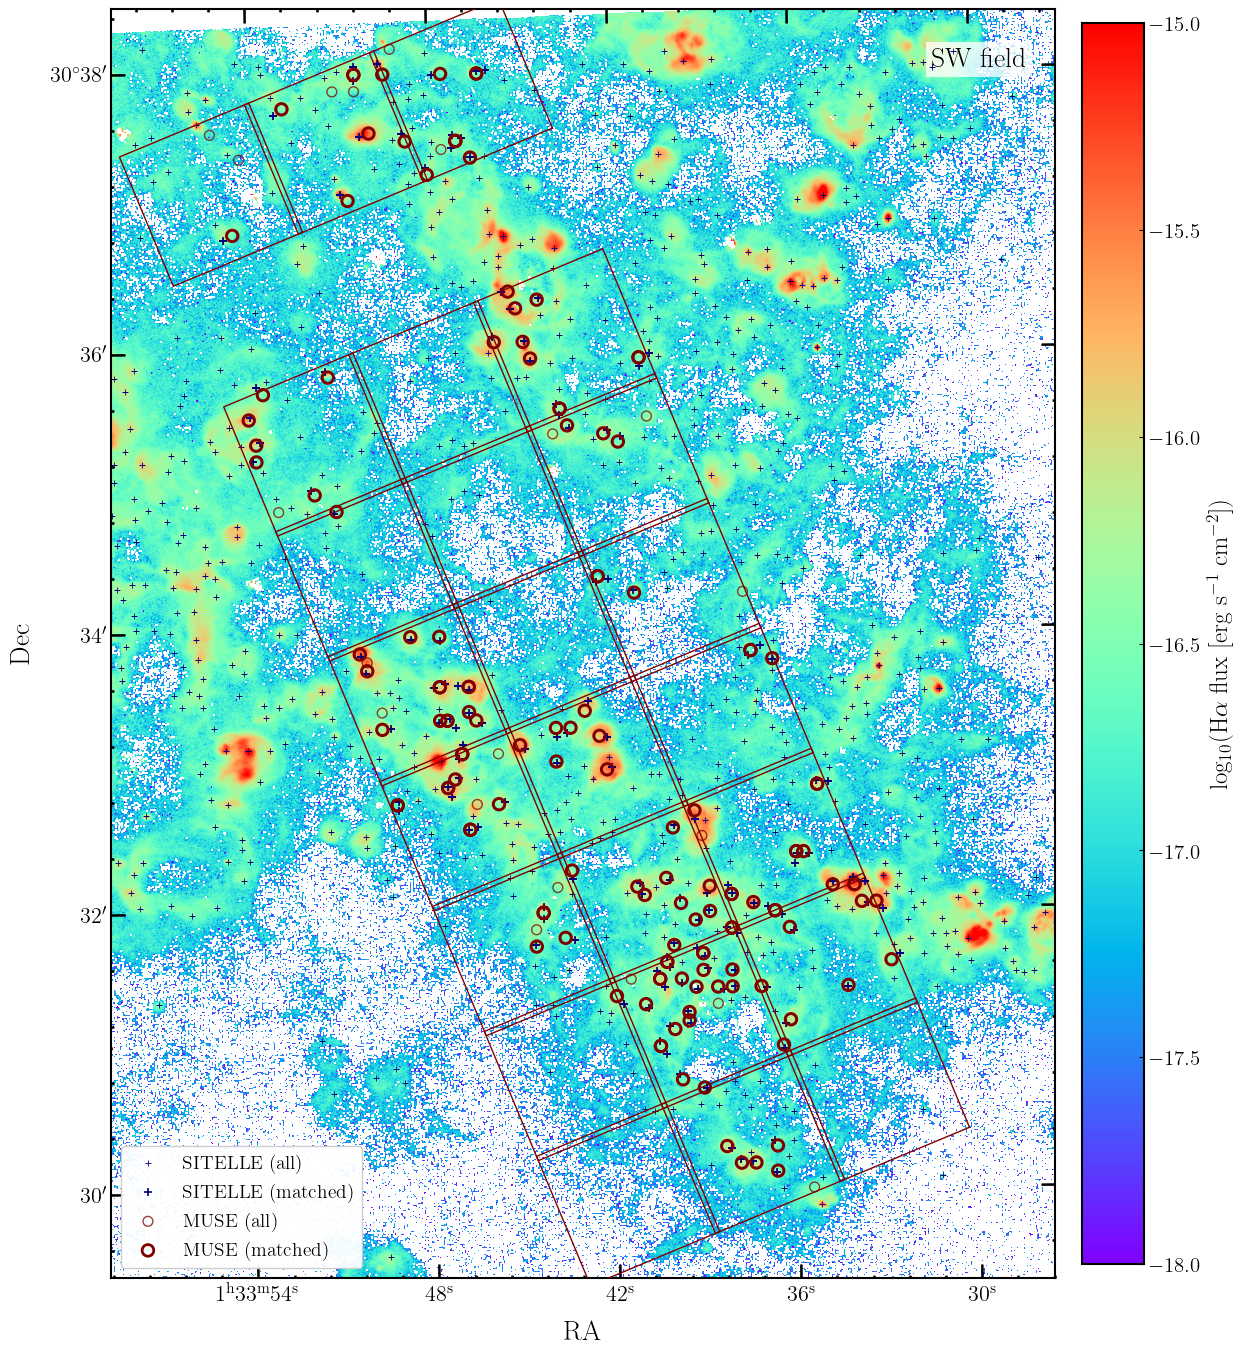

In [51]:
# 1. cross-match

max_sep = 5

matched = crossmatch_sitelle_muse(
    cat_sitelle=cat,   # or your full SITELLE catalog
    muse=muse,
    max_sep_arcsec=max_sep,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
)

print(f"Matched {len(matched)} regions")

# 2. plot
fig, ax = plot_sw_crossmatch_map(
    ha_path="../M33-Maps/M33-SW/M33SW-Haflux.fits",
    sitelle_cat=cat,   # or full catalog
    muse_cat=muse,
    matched=matched,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
    xlim=(50, 1300),
    ylim=(370, 2050),
    figsize=(16, 16),
)

In [52]:
def count_crossmatch_multiplicity(
    sitelle_cat,
    muse_cat,
    max_sep_arcsec=1.5,
    sitelle_ra_col="RA",
    sitelle_dec_col="Dec",
    muse_ra_col="RA",
    muse_dec_col="Dec",
):
    """
    Find ALL SITELLE-MUSE pairs within max_sep_arcsec and count multiplicity.

    Returns
    -------
    pair_table : DataFrame
        One row per candidate pair within the radius.
    sitelle_summary : dict
        Match-count summary for SITELLE peaks.
    muse_summary : dict
        Match-count summary for MUSE regions.
    sitelle_counts : np.ndarray
        Number of MUSE matches for each SITELLE peak.
    muse_counts : np.ndarray
        Number of SITELLE matches for each MUSE region.
    """

    # Coordinates
    sitelle_coords = SkyCoord(
        ra=pd.to_numeric(sitelle_cat[sitelle_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(sitelle_cat[sitelle_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    muse_coords = SkyCoord(
        ra=pd.to_numeric(muse_cat[muse_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(muse_cat[muse_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    # All pairs within radius
    idx_sit, idx_muse, sep2d, _ = search_around_sky(
        sitelle_coords, muse_coords, seplimit=max_sep_arcsec * u.arcsec
    )

    # One row per candidate pair
    pair_table = pd.DataFrame({
        "sitelle_index": idx_sit,
        "muse_index": idx_muse,
        "sep_arcsec": sep2d.arcsec,
    }).sort_values(["sitelle_index", "sep_arcsec"]).reset_index(drop=True)

    # Count how many matches each object has
    sitelle_counts = np.zeros(len(sitelle_cat), dtype=int)
    muse_counts = np.zeros(len(muse_cat), dtype=int)

    if len(pair_table) > 0:
        sit_counts_series = pair_table.groupby("sitelle_index").size()
        muse_counts_series = pair_table.groupby("muse_index").size()

        sitelle_counts[sit_counts_series.index.to_numpy()] = sit_counts_series.to_numpy()
        muse_counts[muse_counts_series.index.to_numpy()] = muse_counts_series.to_numpy()

    # SITELLE summary
    sitelle_summary = {
        "n_total": len(sitelle_cat),
        "n_with_match": int(np.sum(sitelle_counts >= 1)),
        "n_no_match": int(np.sum(sitelle_counts == 0)),
        "n_unique_match": int(np.sum(sitelle_counts == 1)),
        "n_multiple_match": int(np.sum(sitelle_counts > 1)),
    }

    # MUSE summary
    muse_summary = {
        "n_total": len(muse_cat),
        "n_with_match": int(np.sum(muse_counts >= 1)),
        "n_no_match": int(np.sum(muse_counts == 0)),
        "n_unique_match": int(np.sum(muse_counts == 1)),
        "n_multiple_match": int(np.sum(muse_counts > 1)),
    }

    return pair_table, sitelle_summary, muse_summary, sitelle_counts, muse_counts


def mutual_nearest_crossmatch(
    sitelle_cat,
    muse_cat,
    max_sep_arcsec=1.5,
    sitelle_ra_col="RA",
    sitelle_dec_col="Dec",
    muse_ra_col="RA",
    muse_dec_col="Dec",
):
    """
    Build a one-to-one unique matched catalog using mutual nearest neighbours.
    """

    sitelle_coords = SkyCoord(
        ra=pd.to_numeric(sitelle_cat[sitelle_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(sitelle_cat[sitelle_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    muse_coords = SkyCoord(
        ra=pd.to_numeric(muse_cat[muse_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(muse_cat[muse_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    # SITELLE -> nearest MUSE
    idx_sm, sep_sm, _ = sitelle_coords.match_to_catalog_sky(muse_coords)

    # MUSE -> nearest SITELLE
    idx_ms, sep_ms, _ = muse_coords.match_to_catalog_sky(sitelle_coords)

    rows = []
    for i_sit, (i_muse, sep) in enumerate(zip(idx_sm, sep_sm)):
        if sep.arcsec > max_sep_arcsec:
            continue

        # mutual nearest neighbour condition
        if idx_ms[i_muse] == i_sit and sep_ms[i_muse].arcsec <= max_sep_arcsec:
            rows.append({
                "sitelle_index": i_sit,
                "muse_index": int(i_muse),
                "sep_arcsec": float(sep.arcsec),
            })

    unique_matched = pd.DataFrame(rows).sort_values("sep_arcsec").reset_index(drop=True)
    return unique_matched

In [53]:


pair_table, sitelle_summary, muse_summary, sitelle_counts, muse_counts = count_crossmatch_multiplicity(
    sitelle_cat=cat,   # or your full SITELLE SW catalog
    muse_cat=muse,
    max_sep_arcsec=max_sep,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
)

print("SITELLE summary:")
for k, v in sitelle_summary.items():
    print(f"{k}: {v}")

print("\nMUSE summary:")
for k, v in muse_summary.items():
    print(f"{k}: {v}")

unique_pairs = mutual_nearest_crossmatch(
    sitelle_cat=cat_muse,
    muse_cat=muse,
    max_sep_arcsec=max_sep,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
)

print(f"\nNumber of one-to-one unique pairs: {len(unique_pairs)}")

SITELLE summary:
n_total: 963
n_with_match: 137
n_no_match: 826
n_unique_match: 122
n_multiple_match: 15

MUSE summary:
n_total: 131
n_with_match: 114
n_no_match: 17
n_unique_match: 78
n_multiple_match: 36

Number of one-to-one unique pairs: 108


In [54]:
from pathlib import Path

filename = Path("catalog_numbers.tex")

latex_lines = {
    "nSitelleTotalCrossmatch": sitelle_summary["n_total"],
    "nSitelleWithMuseMatch": sitelle_summary["n_with_match"],
    "nSitelleNoMuseMatch": sitelle_summary["n_no_match"],
    "nSitelleUniqueMuseMatch": sitelle_summary["n_unique_match"],
    "nSitelleMultipleMuseMatch": sitelle_summary["n_multiple_match"],
    "nMuseTotalCrossmatch": muse_summary["n_total"],
    "nMuseWithSitelleMatch": muse_summary["n_with_match"],
    "nMuseNoSitelleMatch": muse_summary["n_no_match"],
    "nMuseUniqueSitelleMatch": muse_summary["n_unique_match"],
    "nMuseMultipleSitelleMatch": muse_summary["n_multiple_match"],
    "nUniqueCrossmatchedPairs": len(unique_pairs),
}

if filename.exists():
    content = filename.read_text()
else:
    content = ""

with open(filename, "a") as f:
    for cmd, value in latex_lines.items():
        if f"\\{cmd}" not in content:
            f.write(f"\\newcommand{{\\{cmd}}}{{{value}}}\n")
            print(f"Appended \\{cmd} = {value} to {filename}")

Appended \nSitelleTotalCrossmatch = 963 to catalog_numbers.tex
Appended \nSitelleWithMuseMatch = 137 to catalog_numbers.tex
Appended \nSitelleNoMuseMatch = 826 to catalog_numbers.tex
Appended \nSitelleUniqueMuseMatch = 122 to catalog_numbers.tex
Appended \nSitelleMultipleMuseMatch = 15 to catalog_numbers.tex
Appended \nMuseTotalCrossmatch = 131 to catalog_numbers.tex
Appended \nMuseWithSitelleMatch = 114 to catalog_numbers.tex
Appended \nMuseNoSitelleMatch = 17 to catalog_numbers.tex
Appended \nMuseUniqueSitelleMatch = 78 to catalog_numbers.tex
Appended \nMuseMultipleSitelleMatch = 36 to catalog_numbers.tex
Appended \nUniqueCrossmatchedPairs = 108 to catalog_numbers.tex


In [55]:
muse_multi_idx = np.where(muse_counts > 1)[0]
print("MUSE regions with multiple SITELLE matches:", muse_multi_idx)

muse_multi_pairs = pair_table[pair_table["muse_index"].isin(muse_multi_idx)]
display(muse_multi_pairs.sort_values(["muse_index", "sep_arcsec"]))

MUSE regions with multiple SITELLE matches: [  4   7  12  15  16  21  23  28  29  30  32  34  39  50  58  64  66  68
  73  74  77  80  82  83  86  88  95  96 102 104 105 106 109 115 124 130]


,sitelle_index,muse_index,sep_arcsec
10,129,4,1.986042
8,124,4,4.072784
13,133,7,1.073105
16,140,7,4.317250
27,170,12,3.523399
...,...,...,...
140,894,124,2.688680
142,899,124,3.049071
138,883,124,3.635775
145,934,130,2.587122


In [56]:
sit_multi_idx = np.where(sitelle_counts > 1)[0]
print("SITELLE peaks with multiple MUSE matches:", sit_multi_idx)

sit_multi_pairs = pair_table[pair_table["sitelle_index"].isin(sit_multi_idx)]
display(sit_multi_pairs.sort_values(["sitelle_index", "sep_arcsec"]))

SITELLE peaks with multiple MUSE matches: [ 69 133 140 151 263 276 327 409 480 484 491 538 550 883 934]


,sitelle_index,muse_index,sep_arcsec
1,69,57,1.710733
2,69,58,4.722270
13,133,7,1.073105
14,133,64,4.573492
15,140,64,0.957756
16,140,7,4.317250
20,151,67,2.696414
21,151,66,3.789132
49,263,69,2.470789
50,263,68,3.799510


In [57]:
def build_matched_catalog(
    unique_pairs,
    sitelle_cat,
    muse_cat,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
):
    """
    Combines SITELLE + MUSE data into one matched table.
    """

    sit = sitelle_cat.iloc[unique_pairs["sitelle_index"]].reset_index(drop=True)
    mus = muse_cat.iloc[unique_pairs["muse_index"]].reset_index(drop=True)

    # rename columns to avoid collisions
    sit = sit.add_prefix("sit_")
    mus = mus.add_prefix("muse_")

    matched = pd.concat([sit, mus], axis=1)

    # keep separation too
    matched["sep_arcsec"] = unique_pairs["sep_arcsec"]

    return matched

In [58]:
matched_pairs = mutual_nearest_crossmatch(
    sitelle_cat=cat_muse,
    muse_cat=muse,
    max_sep_arcsec=max_sep,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
)

matched = build_matched_catalog(matched_pairs, cat_muse, muse)

print(len(matched), "unique matched regions")
matched.head()

108 unique matched regions


,sit_region_id,sit_npix_region,sit_npix_edge_ring,sit_F_Halpha_sum,sit_F_Halpha_e_sum,sit_SNR_Halpha_sum,sit_Halpha_b_edge,sit_F_Hbeta_sum,sit_F_Hbeta_e_sum,sit_SNR_Hbeta_sum,...,muse_e_FHeI7065,muse_e_FArIII7135,muse_e_FOII7325,muse_e_FArIII7751,muse_e_FHPa128750,muse_e_FHPa118862,muse_e_FHPa109015,muse_e_FSIII9068,muse_e_FHPa99229,sep_arcsec
0,552.0,63.0,29.0,1.290406e-15,2.197978e-17,58.708760,1.749157e-17,3.772320e-16,3.279983e-17,11.501034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.191131
1,881.0,141.0,59.0,3.083445e-15,4.199282e-17,73.427903,2.067637e-17,7.100439e-16,5.146364e-17,13.797001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262962
2,494.0,281.0,67.0,6.713464e-15,5.086918e-17,131.975075,2.402852e-17,1.687220e-15,6.534864e-17,25.818748,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.382807
3,280.0,1035.0,126.0,5.539494e-14,1.038174e-16,533.580271,3.173281e-17,1.688015e-14,1.556842e-16,108.425552,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.414164
4,412.0,71.0,30.0,3.554681e-15,3.886680e-17,91.458033,4.444585e-17,9.864410e-16,4.114686e-17,23.973664,...,9492.559,9987.821,10188.953,1673.629,14848.388,NaN,NaN,NaN,NaN,0.441810


In [59]:
muse.columns

Index(['recno', 'ID', 'RA', 'Dec', 'Npix', 'Star', 'YSCC', 'EBV', 'ne',
       'OH_Scal', 'OH_N2S2Ha', 'FHb', 'FOIII4958', 'FOIII5006', 'FHeI5015',
       'FNII5754', 'FHeI5875', 'FNII6548', 'FHa6562', 'FNII6583', 'FHeI6678',
       'FSII6716', 'FSII6730', 'FHeI7065', 'FArIII7135', 'FOII7325',
       'FArIII7751', 'FHPa128750', 'FHPa118862', 'FHPa109015', 'FSIII9068',
       'FHPa99229', 'e_FHb', 'e_FOIII4958', 'e_FOIII5006', 'e_FHeI5015',
       'e_FNII5754', 'e_FHeI5875', 'e_FNII6548', 'e_FHa6562', 'e_FNII6583',
       'e_FHeI6678', 'e_FSII6716', 'e_FSII6730', 'e_FHeI7065', 'e_FArIII7135',
       'e_FOII7325', 'e_FArIII7751', 'e_FHPa128750', 'e_FHPa118862',
       'e_FHPa109015', 'e_FSIII9068', 'e_FHPa99229'],
      dtype='object')

In [60]:
# ============================================================
# 1. Compute deprojected galactocentric radius for MUSE regions
# ============================================================
def add_m33_galactocentric_radius(
    df,
    ra_col="RA",
    dec_col="Dec",
    center_ra="01h33m50.9s",
    center_dec="+30d39m36.8s",
    pa_deg=23.0,
    inc_deg=56.0,
    distance_kpc=840.0,
    out_r_col="R_gal_kpc",
    out_x_col="x_deproj_kpc",
    out_y_col="y_deproj_kpc",
):
    """
    Compute deprojected galactocentric radii in the disk plane of M33.

    PA is taken east of north.
    Input RA/Dec must be in degrees.
    """
    ra = pd.to_numeric(df[ra_col], errors="coerce").to_numpy()
    dec = pd.to_numeric(df[dec_col], errors="coerce").to_numpy()

    c0 = SkyCoord(center_ra, center_dec, frame="icrs")
    ra0 = c0.ra.deg
    dec0 = c0.dec.deg

    # tangent-plane offsets in arcsec
    dx_east_arcsec = (ra - ra0) * np.cos(np.deg2rad(dec0)) * 3600.0
    dy_north_arcsec = (dec - dec0) * 3600.0

    # rotate so x_major is along major axis, y_minor along minor axis
    pa = np.deg2rad(pa_deg)
    x_major_arcsec = dx_east_arcsec * np.sin(pa) + dy_north_arcsec * np.cos(pa)
    y_minor_arcsec = -dx_east_arcsec * np.cos(pa) + dy_north_arcsec * np.sin(pa)

    # deproject minor-axis coordinate
    inc = np.deg2rad(inc_deg)
    y_deproj_arcsec = y_minor_arcsec / np.cos(inc)

    # convert arcsec to kpc
    arcsec_to_kpc = distance_kpc / 206265.0
    x_major_kpc = x_major_arcsec * arcsec_to_kpc
    y_deproj_kpc = y_deproj_arcsec * arcsec_to_kpc
    r_kpc = np.hypot(x_major_kpc, y_deproj_kpc)

    out = df.copy()
    out[out_x_col] = x_major_kpc
    out[out_y_col] = y_deproj_kpc
    out[out_r_col] = r_kpc
    return out


# ============================================================
# 2. Mutual-nearest-neighbour unique cross-match
# ============================================================
def mutual_nearest_crossmatch(
    sitelle_cat,
    muse_cat,
    max_sep_arcsec=1.5,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
):
    sit_coords = SkyCoord(
        ra=pd.to_numeric(sitelle_cat[sitelle_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(sitelle_cat[sitelle_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    muse_coords = SkyCoord(
        ra=pd.to_numeric(muse_cat[muse_ra_col], errors="coerce").to_numpy() * u.deg,
        dec=pd.to_numeric(muse_cat[muse_dec_col], errors="coerce").to_numpy() * u.deg,
    )

    idx_sm, sep_sm, _ = sit_coords.match_to_catalog_sky(muse_coords)
    idx_ms, sep_ms, _ = muse_coords.match_to_catalog_sky(sit_coords)

    rows = []
    for i_sit, (i_muse, sep) in enumerate(zip(idx_sm, sep_sm)):
        if sep.arcsec > max_sep_arcsec:
            continue
        if idx_ms[i_muse] == i_sit and sep_ms[i_muse].arcsec <= max_sep_arcsec:
            rows.append({
                "sitelle_index": i_sit,
                "muse_index": int(i_muse),
                "sep_arcsec": float(sep.arcsec),
            })

    return pd.DataFrame(rows).sort_values("sep_arcsec").reset_index(drop=True)


# ============================================================
# 3. Build matched comparison catalog
# ============================================================
def build_matched_catalog(unique_pairs, sitelle_cat, muse_cat):
    sit = sitelle_cat.iloc[unique_pairs["sitelle_index"]].reset_index(drop=True).add_prefix("sit_")
    mus = muse_cat.iloc[unique_pairs["muse_index"]].reset_index(drop=True).add_prefix("muse_")

    matched = pd.concat([sit, mus], axis=1)
    matched["sep_arcsec"] = unique_pairs["sep_arcsec"].to_numpy()
    return matched


# ============================================================
# 4. Flux conversion helper
# ============================================================
def add_muse_flux_erg_columns(muse):
    """
    MUSE catalog fluxes are in units of 1e-20 erg s^-1 cm^-2
    and are already dust-corrected.
    """
    out = muse.copy()
    factor = 1e-20

    flux_map = {
        "FHb": ("FHb_erg", "e_FHb", "e_FHb_erg"),
        "FOIII5006": ("FOIII5006_erg", "e_FOIII5006", "e_FOIII5006_erg"),
        "FHa6562": ("FHa6562_erg", "e_FHa6562", "e_FHa6562_erg"),
        "FNII6583": ("FNII6583_erg", "e_FNII6583", "e_FNII6583_erg"),
        "FSII6716": ("FSII6716_erg", "e_FSII6716", "e_FSII6716_erg"),
        "FSII6730": ("FSII6730_erg", "e_FSII6730", "e_FSII6730_erg"),
    }

    for flux_col, (new_flux, err_col, new_err) in flux_map.items():
        if flux_col in out.columns:
            out[new_flux] = pd.to_numeric(out[flux_col], errors="coerce") * factor
        if err_col in out.columns:
            out[new_err] = pd.to_numeric(out[err_col], errors="coerce") * factor

    return out


# ============================================================
# 5. Generic comparison plot: 1:1 + residual + histograms
# ============================================================
def compare_property_panels(
    df,
    sit_col,
    muse_col,
    xlabel,
    ylabel,
    title=None,
    log10_transform=False,
    residual_label=None,
    bins=25,
):
    x = pd.to_numeric(df[sit_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[muse_col], errors="coerce").to_numpy()

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if log10_transform:
        mask_pos = (x > 0) & (y > 0)
        x = np.log10(x[mask_pos])
        y = np.log10(y[mask_pos])

    resid = x - y

    fig = plt.figure(figsize=(13, 4.5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.0, 1.0], wspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])

    # 1:1
    ax0.scatter(x, y, s=35, alpha=0.8)
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    ax0.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)
    ax0.grid(alpha=0.3)

    # residuals
    ax1.scatter(y, resid, s=35, alpha=0.8)
    ax1.axhline(0, color="k", ls="--", lw=1)
    ax1.set_xlabel(ylabel)
    ax1.set_ylabel(residual_label if residual_label else f"{xlabel} - {ylabel}")
    ax1.grid(alpha=0.3)

    # histograms
    ax2.hist(x, bins=bins, alpha=0.5, density=True, label="SITELLE")
    ax2.hist(y, bins=bins, alpha=0.5, density=True, label="MUSE")
    ax2.set_xlabel("Value")
    ax2.set_ylabel("Density")
    ax2.legend()
    ax2.grid(alpha=0.3)

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. Metallicity gradient comparison
# ============================================================
def plot_metallicity_gradient(
    sitelle_cat,
    muse_cat,
    sit_r_col="R_gal_kpc",
    sit_z_col="Z_N2S2Halpha_Brazzini2024",
    muse_r_col="R_gal_kpc",
    muse_z_col="metallicity_N2S2Ha",
):
    xs = pd.to_numeric(sitelle_cat[sit_r_col], errors="coerce")
    ys = pd.to_numeric(sitelle_cat[sit_z_col], errors="coerce")
    xm = pd.to_numeric(muse_cat[muse_r_col], errors="coerce")
    ym = pd.to_numeric(muse_cat[muse_z_col], errors="coerce")

    ms = np.isfinite(xs) & np.isfinite(ys)
    mm = np.isfinite(xm) & np.isfinite(ym)

    plt.figure(figsize=(7, 5.5))
    plt.scatter(xs[ms], ys[ms], s=25, alpha=0.5, label="SITELLE")
    plt.scatter(xm[mm], ym[mm], s=25, alpha=0.5, label="MUSE")
    plt.xlabel("Galactocentric radius (kpc)")
    plt.ylabel(r"12 + log(O/H)  [N2S2H$\alpha$]")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Optional: matched metallicity gradient only
# ============================================================
def plot_matched_metallicity_vs_radius(matched):
    xs = pd.to_numeric(matched["sit_R_gal_kpc"], errors="coerce")
    ys = pd.to_numeric(matched["sit_Z_N2S2Halpha_Brazzini2024"], errors="coerce")
    xm = pd.to_numeric(matched["muse_R_gal_kpc"], errors="coerce")
    ym = pd.to_numeric(matched["muse_metallicity_N2S2Ha"], errors="coerce")

    ms = np.isfinite(xs) & np.isfinite(ys)
    mm = np.isfinite(xm) & np.isfinite(ym)

    plt.figure(figsize=(7, 5.5))
    plt.scatter(xs[ms], ys[ms], s=35, alpha=0.8, label="SITELLE matched")
    plt.scatter(xm[mm], ym[mm], s=35, alpha=0.8, label="MUSE matched")
    plt.xlabel("Galactocentric radius (kpc)")
    plt.ylabel(r"12 + log(O/H)  [N2S2H$\alpha$]")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [61]:
muse = muse.dropna(subset=["RA", "Dec"]).reset_index(drop=True)

# add fluxes in erg/s/cm^2
muse = add_muse_flux_erg_columns(muse)

# add galactocentric radius
muse = add_m33_galactocentric_radius(muse, ra_col="RA", dec_col="Dec")
muse.columns

Index(['recno', 'ID', 'RA', 'Dec', 'Npix', 'Star', 'YSCC', 'EBV', 'ne',
       'OH_Scal', 'OH_N2S2Ha', 'FHb', 'FOIII4958', 'FOIII5006', 'FHeI5015',
       'FNII5754', 'FHeI5875', 'FNII6548', 'FHa6562', 'FNII6583', 'FHeI6678',
       'FSII6716', 'FSII6730', 'FHeI7065', 'FArIII7135', 'FOII7325',
       'FArIII7751', 'FHPa128750', 'FHPa118862', 'FHPa109015', 'FSIII9068',
       'FHPa99229', 'e_FHb', 'e_FOIII4958', 'e_FOIII5006', 'e_FHeI5015',
       'e_FNII5754', 'e_FHeI5875', 'e_FNII6548', 'e_FHa6562', 'e_FNII6583',
       'e_FHeI6678', 'e_FSII6716', 'e_FSII6730', 'e_FHeI7065', 'e_FArIII7135',
       'e_FOII7325', 'e_FArIII7751', 'e_FHPa128750', 'e_FHPa118862',
       'e_FHPa109015', 'e_FSIII9068', 'e_FHPa99229', 'FHb_erg', 'e_FHb_erg',
       'FOIII5006_erg', 'e_FOIII5006_erg', 'FHa6562_erg', 'e_FHa6562_erg',
       'FNII6583_erg', 'e_FNII6583_erg', 'FSII6716_erg', 'e_FSII6716_erg',
       'FSII6730_erg', 'e_FSII6730_erg', 'x_deproj_kpc', 'y_deproj_kpc',
       'R_gal_kpc'],
      dtype

In [62]:
for col in matched.columns:
    print(col)

sit_region_id
sit_npix_region
sit_npix_edge_ring
sit_F_Halpha_sum
sit_F_Halpha_e_sum
sit_SNR_Halpha_sum
sit_Halpha_b_edge
sit_F_Hbeta_sum
sit_F_Hbeta_e_sum
sit_SNR_Hbeta_sum
sit_Hbeta_b_edge
sit_F_[OIII]5007_sum
sit_F_[OIII]5007_e_sum
sit_SNR_[OIII]5007_sum
sit_[OIII]5007_b_edge
sit_F_[SII]6716_sum
sit_F_[SII]6716_e_sum
sit_SNR_[SII]6716_sum
sit_[SII]6716_b_edge
sit_F_[SII]6731_sum
sit_F_[SII]6731_e_sum
sit_SNR_[SII]6731_sum
sit_[SII]6731_b_edge
sit_F_[NII]6583_sum
sit_F_[NII]6583_e_sum
sit_SNR_[NII]6583_sum
sit_[NII]6583_b_edge
sit_F_[OII]3727_sum
sit_F_[OII]3727_e_sum
sit_SNR_[OII]3727_sum
sit_[OII]3727_b_edge
sit_field
sit_y
sit_x
sit_removed_by_saddle
sit_removed_by_edge
sit_kind
sit_center_x_px
sit_center_y_px
sit_zoi_center_label
sit_bg_local
sit_sigma_local
sit_radius_p16_px
sit_radius_p50_px
sit_radius_p84_px
sit_radius_p16_pc
sit_radius_p50_pc
sit_radius_p84_pc
sit_radius_areaeq_px
sit_radius_areaeq_pc
sit_boundary_method
sit_area_px_after_carve
sit_radius_areaeq_px_after_carv

In [63]:
# #compare sitelle and muse errors on h alpha flux
# plt.scatter(matched["muse_e_FHa6562_erg"], matched["e_FHa6562_erg"], s=35, alpha=0.8)

In [64]:
unique_pairs = mutual_nearest_crossmatch(
    sitelle_cat=cat_muse,   # or cat if you prefer
    muse_cat=muse,
    max_sep_arcsec=max_sep,
    sitelle_ra_col="RA_deg",
    sitelle_dec_col="Dec_deg",
    muse_ra_col="RA",
    muse_dec_col="Dec",
)

matched = build_matched_catalog(unique_pairs, cat_muse, muse)

print(f"Unique one-to-one matches: {len(matched)}")

Unique one-to-one matches: 108


In [65]:
for col in cat.columns:
    print(col)

region_id
npix_region
npix_edge_ring
F_Halpha_sum
F_Halpha_e_sum
SNR_Halpha_sum
Halpha_b_edge
F_Hbeta_sum
F_Hbeta_e_sum
SNR_Hbeta_sum
Hbeta_b_edge
F_[OIII]5007_sum
F_[OIII]5007_e_sum
SNR_[OIII]5007_sum
[OIII]5007_b_edge
F_[SII]6716_sum
F_[SII]6716_e_sum
SNR_[SII]6716_sum
[SII]6716_b_edge
F_[SII]6731_sum
F_[SII]6731_e_sum
SNR_[SII]6731_sum
[SII]6731_b_edge
F_[NII]6583_sum
F_[NII]6583_e_sum
SNR_[NII]6583_sum
[NII]6583_b_edge
F_[OII]3727_sum
F_[OII]3727_e_sum
SNR_[OII]3727_sum
[OII]3727_b_edge
field
y
x
removed_by_saddle
removed_by_edge
kind
center_x_px
center_y_px
zoi_center_label
bg_local
sigma_local
radius_p16_px
radius_p50_px
radius_p84_px
radius_p16_pc
radius_p50_pc
radius_p84_pc
radius_areaeq_px
radius_areaeq_pc
boundary_method
area_px_after_carve
radius_areaeq_px_after_carve
radius_areaeq_pc_after_carve
id_int
x_int
y_int
FIELD_int
F_[OII]3727_int
F_[OII]3727_e_int
SNR_[OII]3727_int
F_Hbeta_int
F_Hbeta_e_int
SNR_Hbeta_int
F_[OIII]4959_int
F_[OIII]4959_e_int
SNR_[OIII]4959_int
F_[OI

In [117]:
def compare_property_panels_with_errors(
    df,
    sit_col,
    muse_col,
    save_name=None,
    sit_err_col=None,
    muse_err_col=None,
    xlabel=None,
    ylabel=None,
    title=None,
    log10_transform=False,
    residual_label=None,
    lin = None,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import AutoMinorLocator

    # --- Data prep ---
    x = pd.to_numeric(df[sit_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[muse_col], errors="coerce").to_numpy()

    if sit_err_col is not None:
        xerr = pd.to_numeric(df[sit_err_col], errors="coerce").to_numpy()
    else:
        xerr = np.full_like(x, np.nan, dtype=float)

    if muse_err_col is not None:
        yerr = pd.to_numeric(df[muse_err_col], errors="coerce").to_numpy()
    else:
        yerr = np.full_like(y, np.nan, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y, xerr, yerr = x[mask], y[mask], xerr[mask], yerr[mask]

    if log10_transform:
        good = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x, y, xerr, yerr = x[good], y[good], xerr[good], yerr[good]

        with np.errstate(invalid="ignore", divide="ignore"):
            xerr = xerr / (x * np.log(10))
            yerr = yerr / (y * np.log(10))
            x = np.log10(x)
            y = np.log10(y)

    resid = x - y
    resid_err = np.sqrt(
        np.where(np.isfinite(xerr), xerr, 0.0) ** 2 +
        np.where(np.isfinite(yerr), yerr, 0.0) ** 2
    )

    # --- Labels ---
    xlab = xlabel if xlabel else sit_col
    ylab = ylabel if ylabel else muse_col
    rlab = residual_label if residual_label else "Residual"

    color = 'navy'

    # --- Figure ---
    fig, (ax0, ax1) = plt.subplots(
        2, 1,
        figsize=(7.2, 8.4),
        sharex=True,
        gridspec_kw={"height_ratios": [3.3, 1], "hspace": 0.04}
    )

    # ---------- Top: 1:1 ----------
    ax0.errorbar(
        x, y,
        xerr=xerr if np.isfinite(xerr).any() else None,
        yerr=yerr if np.isfinite(yerr).any() else None,
        fmt="o",
        ms=6.5,                      # bigger points
        alpha=0.9,
        elinewidth=1.0,
        capsize=2,
        color=color,
        mec="white",                 # white edge for clarity
        mew=0.6
    )

    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    span = hi - lo
    pad = 0.08 * span if span > 0 else 1.0

    ax0.plot([lo, hi], [lo, hi], ls="--", lw=1.0, color="0.4", zorder=0)

    ax0.set_xlim(lo - pad, hi + pad)
    ax0.set_ylim(lo - pad, hi + pad)
    ax0.set_ylabel(ylab, fontsize=12)
    
    #add text for the emission line name
    if lin is not None:
        ax0.text(
            0.05, 0.95, lin,
            transform=ax0.transAxes,
            ha="left", va="top",
            fontsize=14,
        color=color,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=4),
    )

    # ---------- Bottom: residuals ----------
    ax1.errorbar(
        x, resid,
        xerr=xerr if np.isfinite(xerr).any() else None,
        yerr=resid_err if np.isfinite(resid_err).any() else None,
        fmt="o",
        ms=6.5,
        alpha=0.9,
        elinewidth=1.0,
        capsize=2,
        color=color,
        mec="white",
        mew=0.6
    )

    ax1.axhline(0, ls="--", lw=1.0, color="0.4", zorder=0)

    # --- Force symmetric residual limits ---
    max_abs = np.nanmax(np.abs(resid))
    pad = 0.15 * max_abs if max_abs > 0 else 0.1
    lim = max_abs + pad
    ax1.set_ylim(-lim, +lim)

    ax1.set_xlabel(xlab, fontsize=12)
    ax1.set_ylabel(rlab, fontsize=11)

    # ---------- Styling ----------
    for ax in (ax0, ax1):
        ax.tick_params(
            which="major",
            direction="in",
            top=True,
            right=True,
            length=6,
            width=1.0,
            labelsize=10
        )
        ax.tick_params(
            which="minor",
            direction="in",
            top=True,
            right=True,
            length=3.5,
            width=0.8
        )

        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))

        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    ax0.tick_params(labelbottom=False)

    if title is not None:
        fig.suptitle(title, fontsize=13, y=0.98)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/4094058126.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


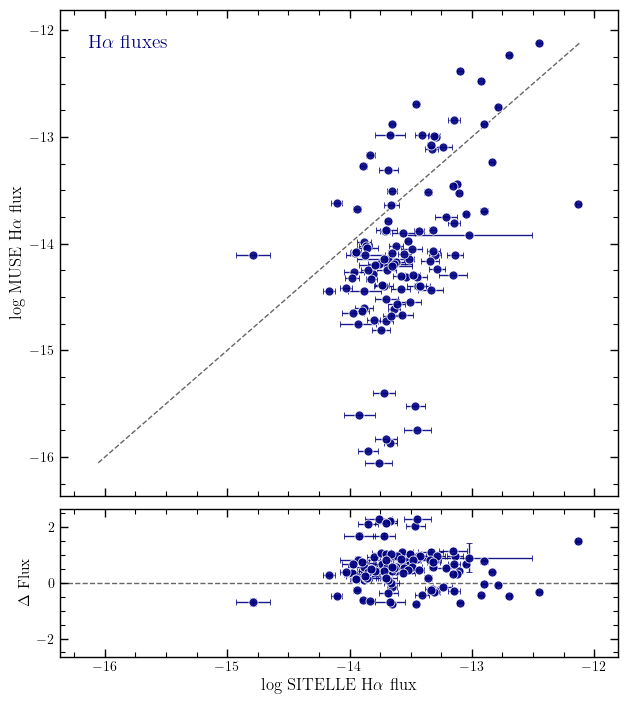

In [121]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_Halpha_int_dered",
    muse_col="muse_FHa6562_erg",
    sit_err_col="sit_F_Halpha_e_int_dered",
    muse_err_col="muse_e_FHa6562_erg",
    xlabel=r"log SITELLE H$\alpha$ flux",
    ylabel=r"log MUSE H$\alpha$ flux",
    log10_transform=True,
    residual_label=r"$\Delta$ Flux",
    save_name="PAPER_PLOTS/matched_Halpha_flux_comparison.png",
    lin = r'H$\alpha$ fluxes',
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/4094058126.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


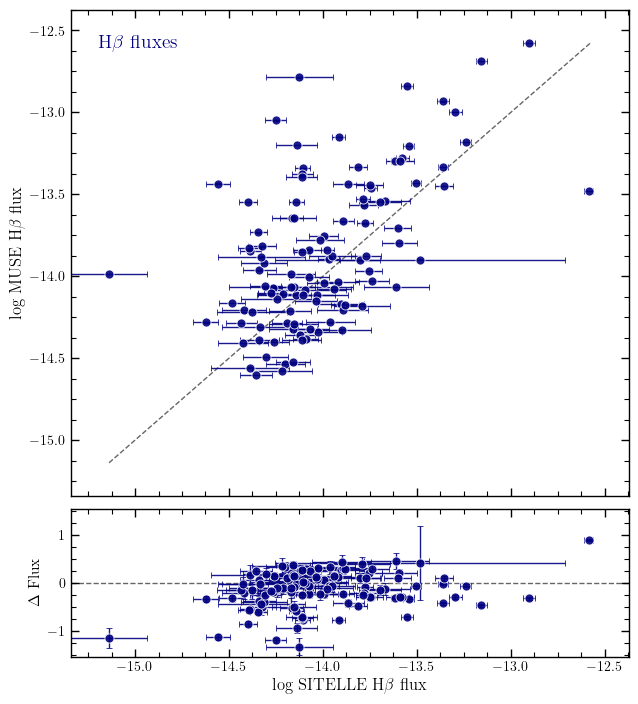

In [123]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_Hbeta_int_dered",
    muse_col="muse_FHb_erg",
    sit_err_col="sit_F_Hbeta_e_int_dered",
    muse_err_col="muse_e_FHb_erg",
    xlabel=r"log SITELLE H$\beta$ flux",
    ylabel=r"log MUSE H$\beta$ flux",
    log10_transform=True,
    residual_label=r"$\Delta$ Flux",
    save_name="PAPER_PLOTS/matched_Hbeta_flux_comparison.png",
    lin = r'H$\beta$ fluxes')

In [124]:
def compare_property_panels_with_errors(
    df,
    sit_col,
    muse_col,
    save_name=None,
    sit_err_col=None,
    muse_err_col=None,
    xlabel=None,
    ylabel=None,
    title=None,
    log10_transform=False,
    residual_label=None,
    bins=25,
    sitelle_colour = 'navy',
    muse_colour = 'maroon',
    
):
    x = pd.to_numeric(df[sit_col], errors="coerce").to_numpy()
    y = pd.to_numeric(df[muse_col], errors="coerce").to_numpy()

    if sit_err_col is not None:
        xerr = pd.to_numeric(df[sit_err_col], errors="coerce").to_numpy()
    else:
        xerr = np.full_like(x, np.nan, dtype=float)

    if muse_err_col is not None:
        yerr = pd.to_numeric(df[muse_err_col], errors="coerce").to_numpy()
    else:
        yerr = np.full_like(y, np.nan, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y, xerr, yerr = x[mask], y[mask], xerr[mask], yerr[mask]

    if log10_transform:
        good = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x, y, xerr, yerr = x[good], y[good], xerr[good], yerr[good]

        # propagate errors into log10 space
        with np.errstate(invalid="ignore", divide="ignore"):
            xerr = xerr / (x * np.log(10))
            yerr = yerr / (y * np.log(10))
            x = np.log10(x)
            y = np.log10(y)

    resid = x - y
    resid_err = np.sqrt(
        np.where(np.isfinite(xerr), xerr, 0.0)**2 +
        np.where(np.isfinite(yerr), yerr, 0.0)**2
    )

    fig = plt.figure(figsize=(20, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.0, 1.0], wspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])

    # 1:1 panel
    ax0.errorbar(
        x, y,
        xerr=xerr if np.isfinite(xerr).any() else None,
        yerr=yerr if np.isfinite(yerr).any() else None,
        fmt="o",
        ms=4.5,
        alpha=0.75,
        elinewidth=0.8,
        capsize=1,
        color = 'k'
    )
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    ax0.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax0.set_xlabel(xlabel if xlabel else sit_col)
    ax0.set_ylabel(ylabel if ylabel else muse_col)

    ax0.set_ylim(min(lo, hi)-0.1*(max(lo, hi)-min(lo, hi)), max(lo, hi)+0.1*(max(lo, hi)-min(lo, hi)))
    ax0.set_xlim(min(lo, hi)-0.1*(max(lo, hi)-min(lo, hi)), max(lo, hi)+0.1*(max(lo, hi)-min(lo, hi)))

    # residual panel
    ax1.errorbar(
        x, resid,
        yerr=None,
        fmt="o",
        ms=4.5,
        alpha=0.75,
        elinewidth=0.8,
        capsize=1,
        color = 'k'
    )
    ax1.axhline(0, color="k", ls="--", lw=1)
    ax1.set_xlabel(xlabel if xlabel else sit_col)
    ax1.set_ylabel(residual_label if residual_label else f"{xlabel} - {ylabel}")
    ax1.set_ylim(min(resid)-0.1*(max(resid)-min(resid)), max(resid)+0.1*(max(resid)-min(resid)))
    ax1.set_xlim(min(x)-0.1*(max(x)-min(x)), max(x)+0.1*(max(x)-min(x)))
    # histogram panel
    ax2.hist(x, bins=bins, alpha=0.5, density=True, label="SITELLE", color=sitelle_colour)
    ax2.hist(y, bins=bins, alpha=0.5, density=True, label="MUSE", color=muse_colour)
    ax2.set_xlabel("Flux (erg s$^{-1}$ cm$^{-2}$)" if "flux" in xlabel.lower() else "Value")
    ax2.set_ylabel("Density")
    ax2.legend(loc = 'upper left')
    

    if title is not None:
        fig.suptitle(title, y=1.02)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

In [93]:
# #divide halpha and nii fluxes in sitelle catalog by 0.88, maybe calibration issue?
# matched["sit_F_Halpha_int_dered"] /= 0.88
# matched["sit_F_Halpha_e_int_dered"] /= 0.88
# matched["sit_F_[NII]6583_int_dered"] /= 0.88
# matched["sit_F_[NII]6583_e_int_dered"] /= 0.88

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


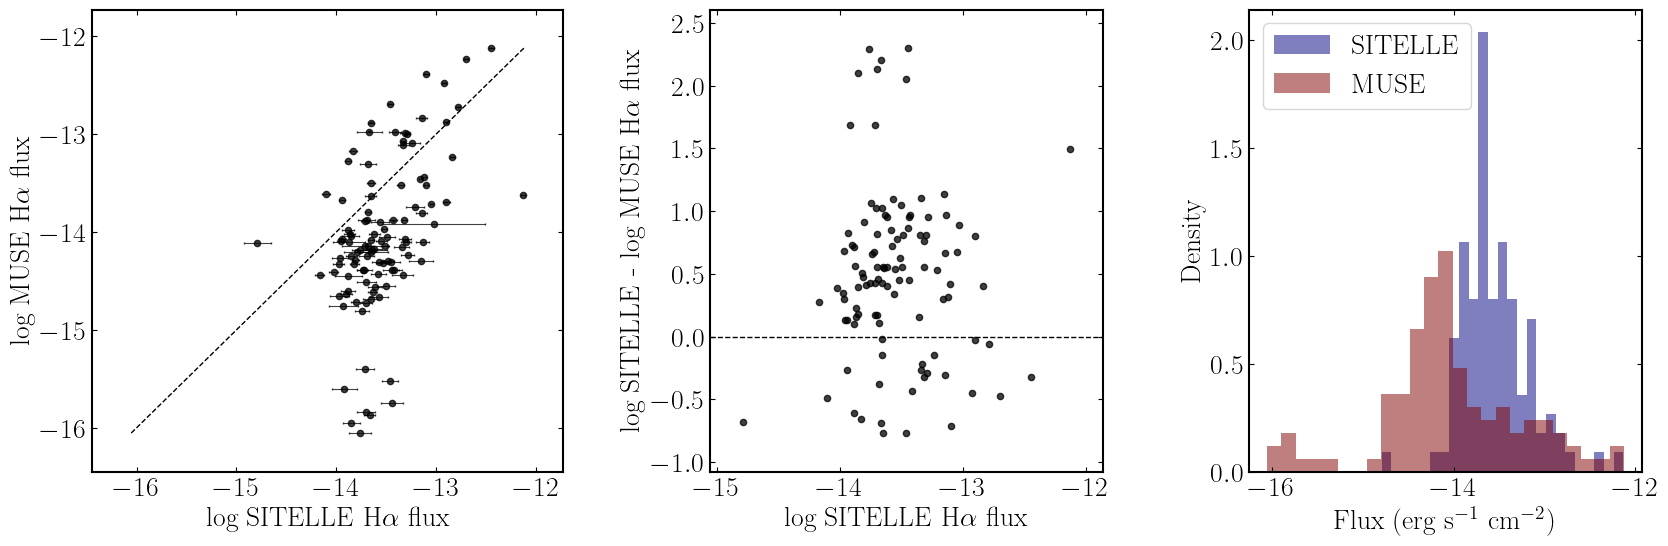

In [94]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_Halpha_int_dered",
    muse_col="muse_FHa6562_erg",
    sit_err_col="sit_F_Halpha_e_int_dered",
    muse_err_col="muse_e_FHa6562_erg",
    xlabel=r"log SITELLE H$\alpha$ flux",
    ylabel=r"log MUSE H$\alpha$ flux",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE H$\alpha$ flux",
    save_name="PAPER_PLOTS/matched_Halpha_flux_comparison.png",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


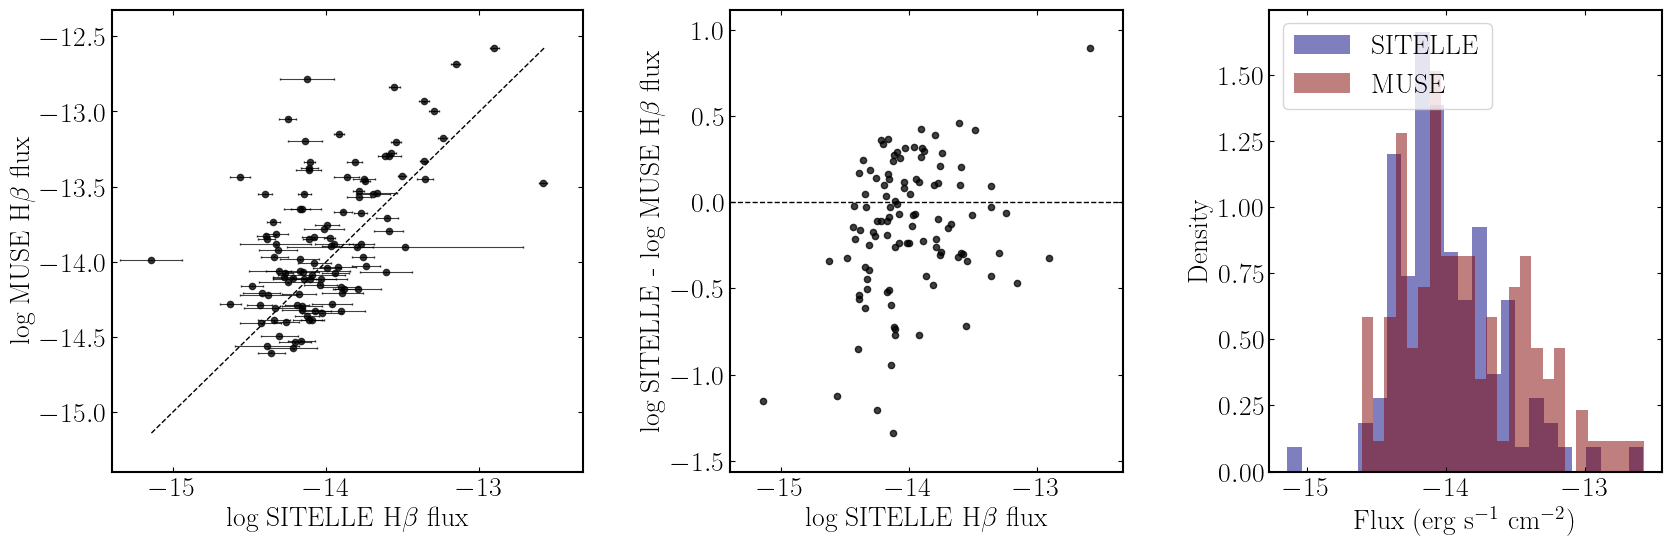

In [69]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_Hbeta_int_dered",
    muse_col="muse_FHb_erg",
    sit_err_col="sit_F_Hbeta_e_int_dered",
    muse_err_col="muse_e_FHb_erg",
    xlabel=r"log SITELLE H$\beta$ flux",
    ylabel=r"log MUSE H$\beta$ flux",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE H$\beta$ flux",
    save_name="PAPER_PLOTS/matched_Hbeta_flux_comparison.png",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


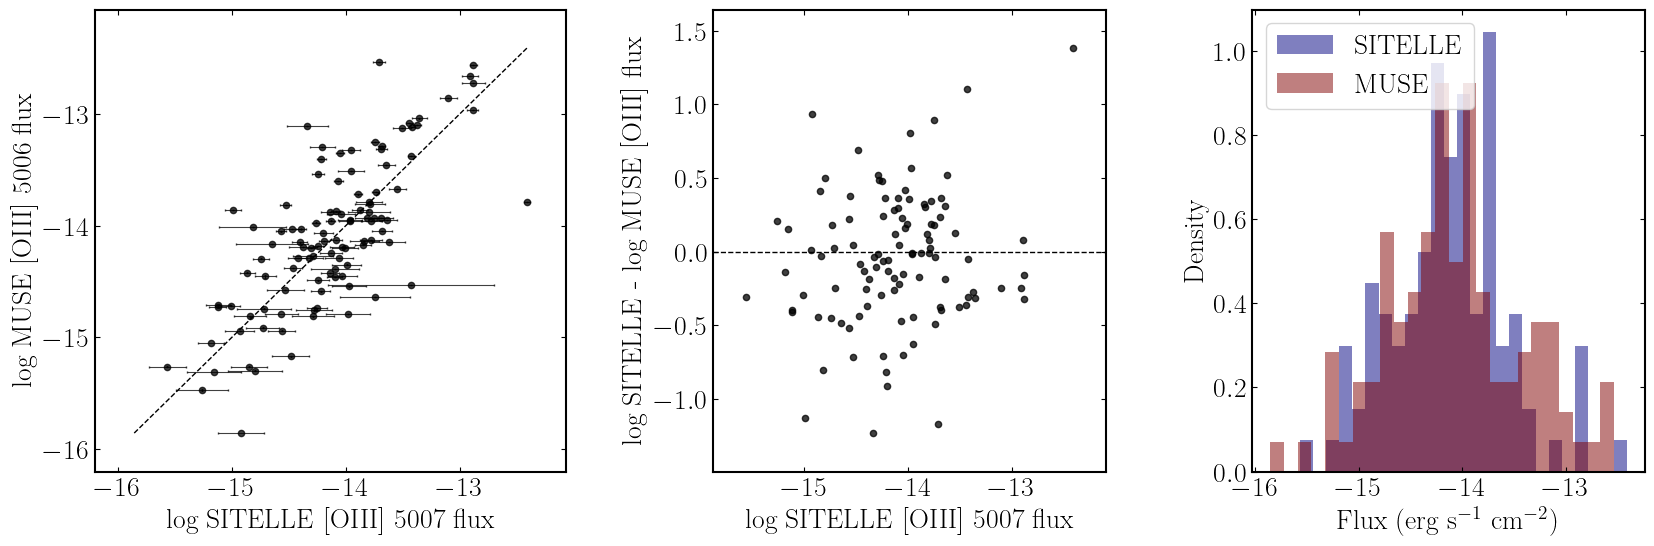

In [70]:
# compare OIII lines
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_[OIII]5007_int_dered",
    muse_col="muse_FOIII5006_erg",
    sit_err_col="sit_F_[OIII]5007_e_int_dered",
    muse_err_col="muse_e_FOIII5006_erg",
    xlabel=r"log SITELLE [OIII] 5007 flux",
    ylabel=r"log MUSE [OIII] 5006 flux",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE [OIII] flux",
    save_name="PAPER_PLOTS/matched_OIII_flux_comparison.png",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


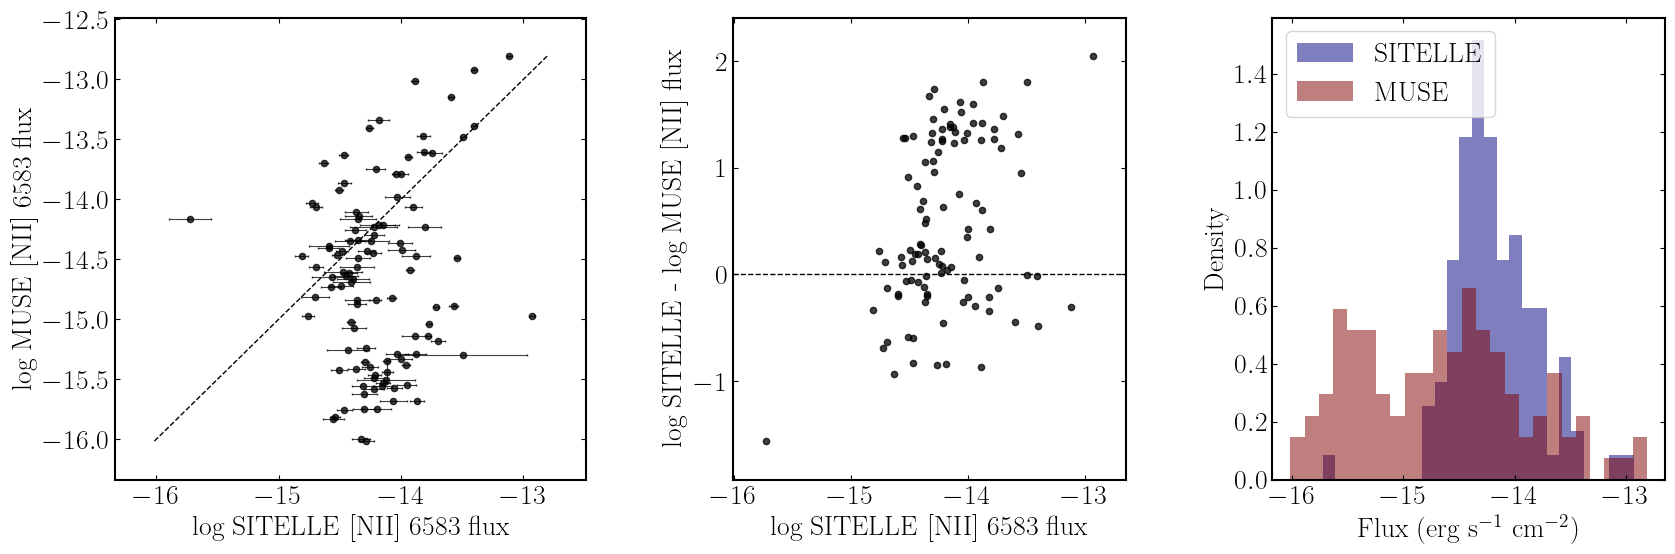

In [71]:
# compare NII line
compare_property_panels_with_errors(
    matched,
    sit_col="sit_F_[NII]6583_int_dered",
    muse_col="muse_FNII6583_erg",
    sit_err_col="sit_F_[NII]6583_e_int_dered",
    muse_err_col="muse_e_FNII6583_erg",
    xlabel=r"log SITELLE [NII] 6583 flux",
    ylabel=r"log MUSE [NII] 6583 flux",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE [NII] flux",
    save_name="PAPER_PLOTS/matched_NII_flux_comparison.png",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


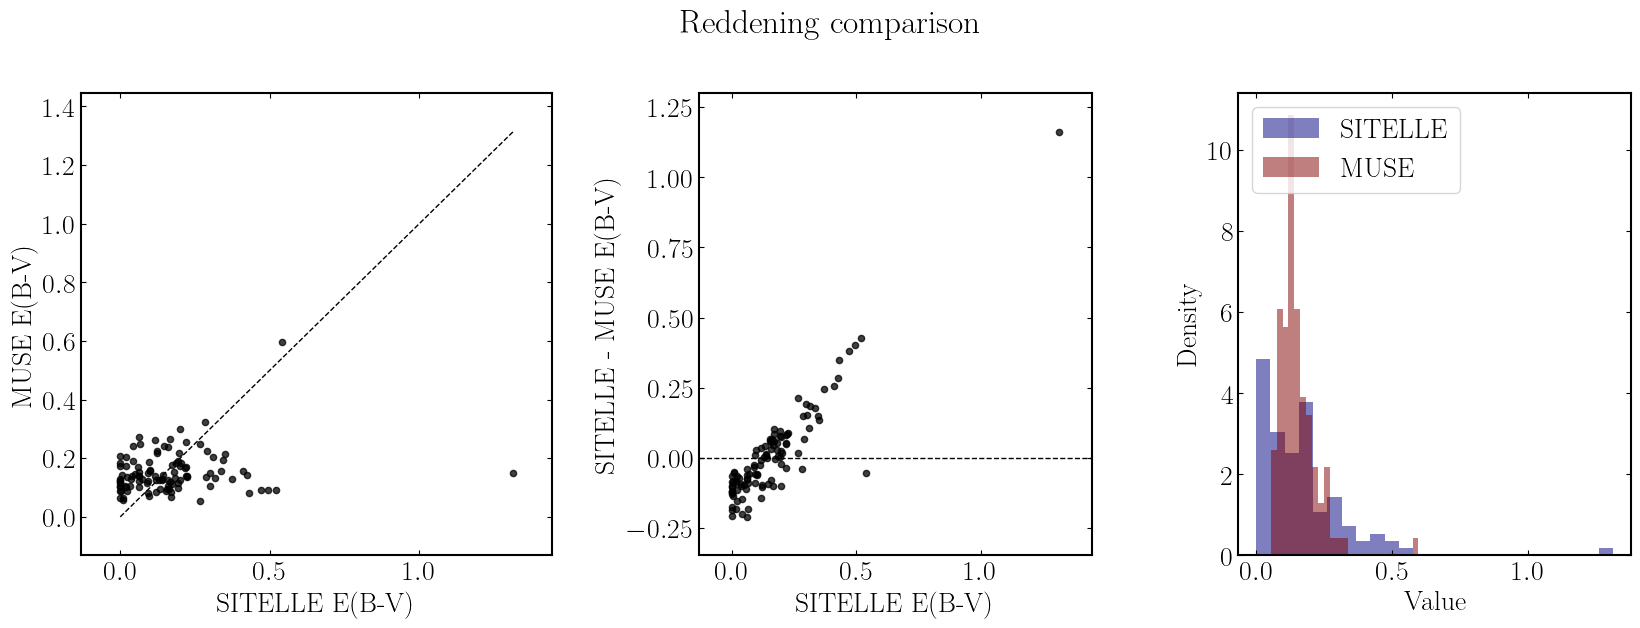

In [72]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_int_E_BV",
    muse_col="muse_EBV",
    sit_err_col=None,
    muse_err_col=None,
    xlabel="SITELLE E(B-V)",
    ylabel="MUSE E(B-V)",
    title="Reddening comparison",
    log10_transform=False,
    residual_label="SITELLE - MUSE E(B-V)"
)

# Ignore everyting below here, it is just testing stuff...

In [73]:
# compare_property_panels(
#     matched,
#     sit_col="sit_Z_N2S2Halpha_Brazzini2024",
#     muse_col="muse_metallicity_N2S2Ha",
#     xlabel="SITELLE 12 + log(O/H)",
#     ylabel="MUSE 12 + log(O/H)",
#     title="Metallicity comparison N2S2Halpha_Brazzini2024",
#     log10_transform=False,
#     residual_label="SITELLE - MUSE metallicity",
# )

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/979539804.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


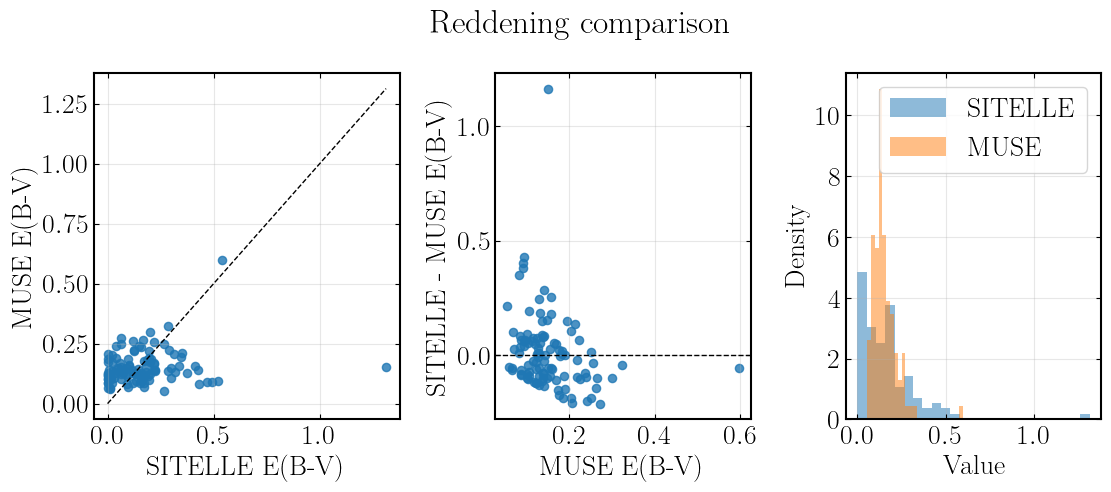

In [74]:
compare_property_panels(
    matched,
    sit_col="sit_int_E_BV",
    muse_col="muse_EBV",
    xlabel="SITELLE E(B-V)",
    ylabel="MUSE E(B-V)",
    title="Reddening comparison",
    log10_transform=False,
    residual_label="SITELLE - MUSE E(B-V)",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/979539804.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


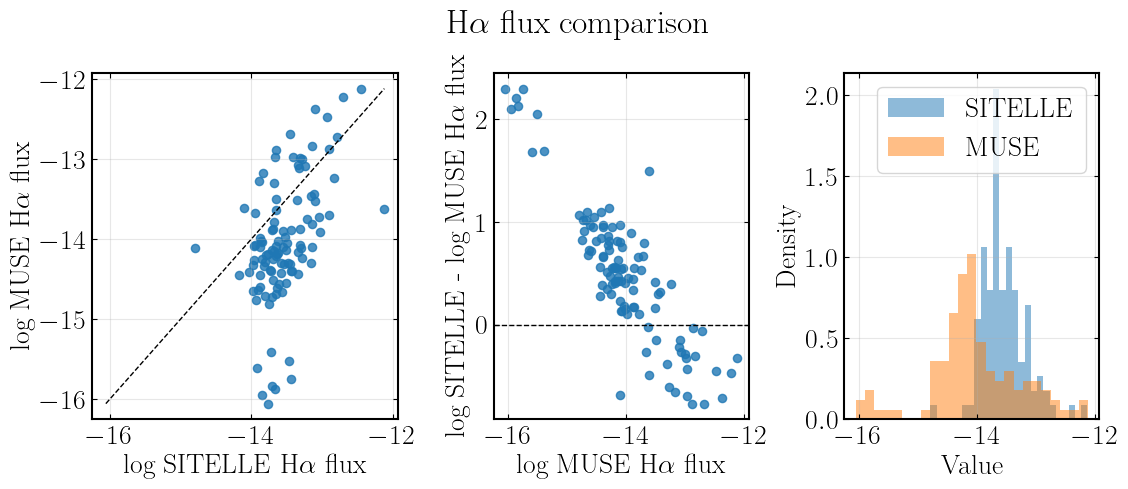

In [75]:
compare_property_panels(
    matched,
    sit_col="sit_F_Halpha_int_dered",
    muse_col="muse_FHa6562_erg",
    xlabel=r"log SITELLE H$\alpha$ flux",
    ylabel=r"log MUSE H$\alpha$ flux",
    title=r"H$\alpha$ flux comparison",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE H$\alpha$ flux",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/979539804.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


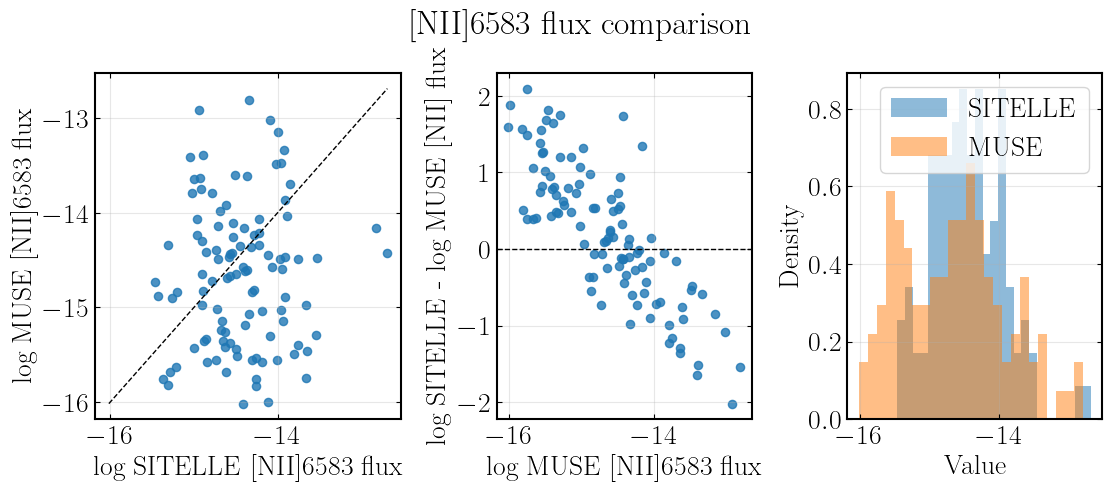

In [76]:
compare_property_panels(
    matched,
    sit_col="sit_F_[NII]6583_sum_dered",
    muse_col="muse_FNII6583_erg",
    xlabel=r"log SITELLE [NII]6583 flux",
    ylabel=r"log MUSE [NII]6583 flux",
    title="[NII]6583 flux comparison",
    log10_transform=True,
    residual_label=r"log SITELLE - log MUSE [NII] flux",
)

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/979539804.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


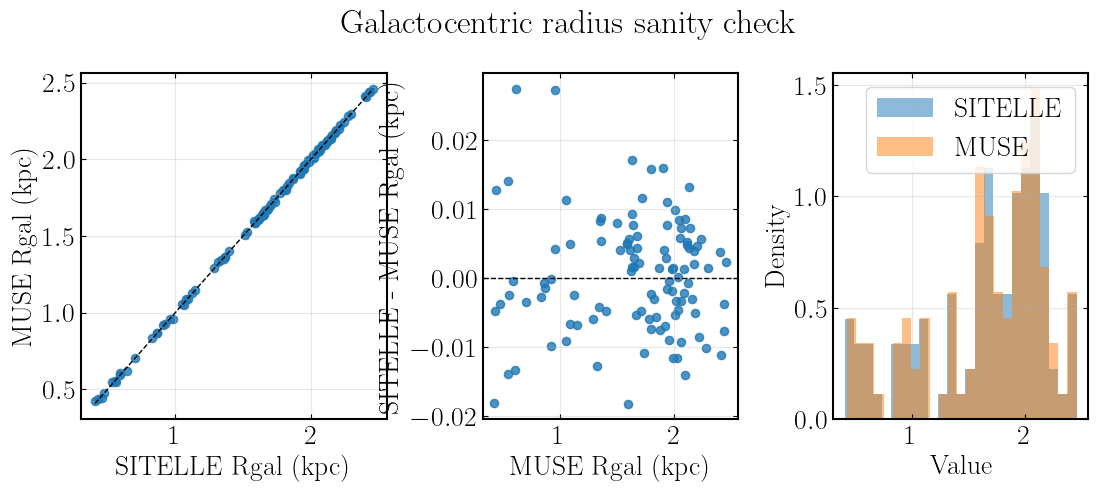

In [77]:
compare_property_panels(
    matched,
    sit_col="sit_R_gal_kpc",
    muse_col="muse_R_gal_kpc",
    xlabel="SITELLE Rgal (kpc)",
    ylabel="MUSE Rgal (kpc)",
    title="Galactocentric radius sanity check",
    log10_transform=False,
    residual_label="SITELLE - MUSE Rgal (kpc)",
)

In [78]:
muse['e_FHeI7065']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
126   NaN
127   NaN
128   NaN
129   NaN
130   NaN
Name: e_FHeI7065, Length: 131, dtype: float64

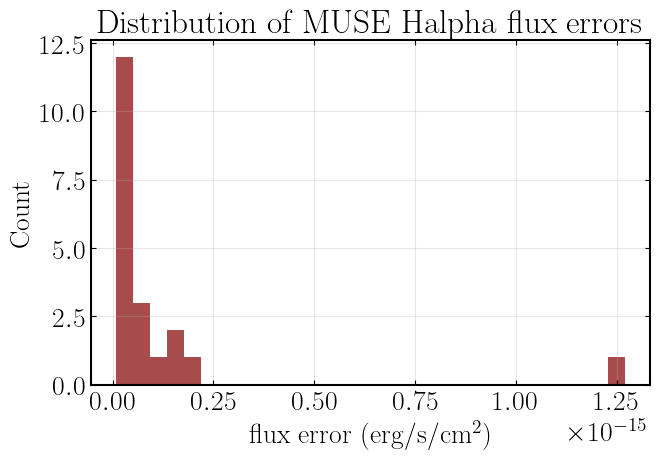

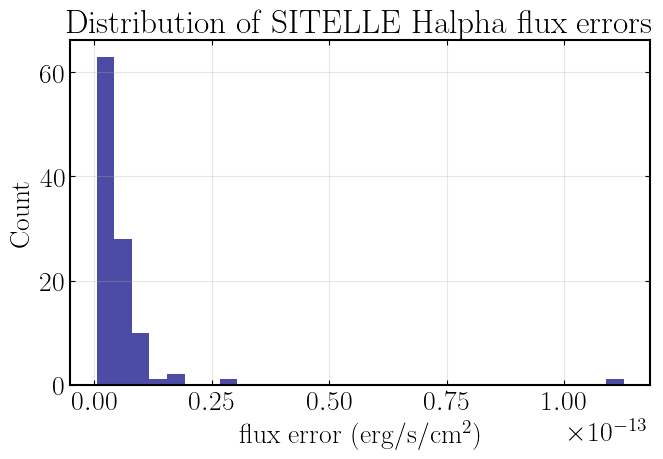

In [79]:
#plot a histogram of muse errors and sitelle
plt.figure(figsize=(7, 5))
plt.hist(matched["muse_e_FHa6562_erg"], bins=30, alpha=0.7, color='maroon', label='MUSE Halpha flux errors')
plt.xlabel(r"flux error (erg/s/cm$^2$)")
plt.ylabel("Count")
plt.title("Distribution of MUSE Halpha flux errors")
plt.grid(alpha=0.3)
plt.tight_layout()

#plot a histogram of muse errors and sitelle
plt.figure(figsize=(7, 5))
plt.hist(matched["sit_F_Halpha_e_int_dered"], bins=30, alpha=0.7, color='navy', label='SITELLE Halpha flux errors')
plt.xlabel(r"flux error (erg/s/cm$^2$)")
plt.ylabel("Count")
plt.title("Distribution of SITELLE Halpha flux errors")
plt.grid(alpha=0.3)
plt.tight_layout()

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_39449/3301238386.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


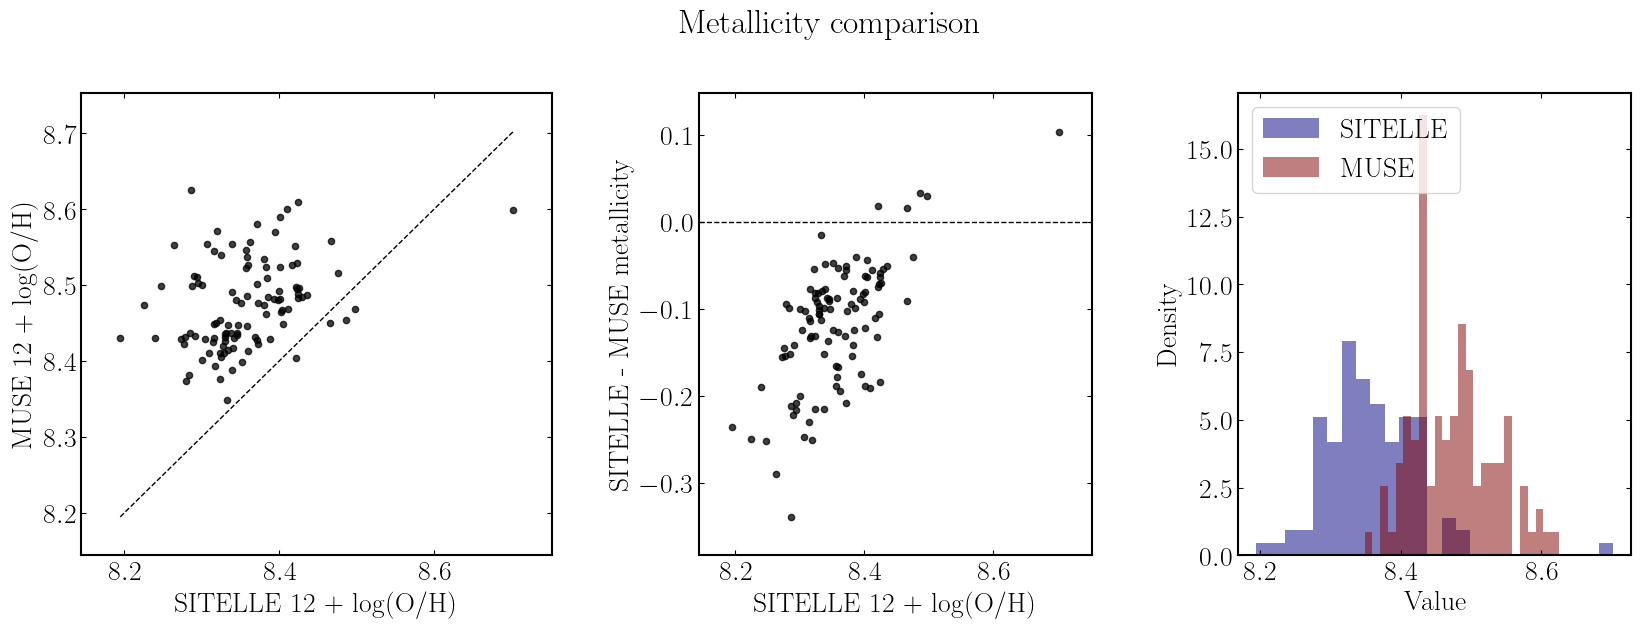

In [80]:
compare_property_panels_with_errors(
    matched,
    sit_col="sit_Z_N2S2Halpha_Brazzini2024",
    muse_col="muse_OH_N2S2Ha",
    sit_err_col=None,
    muse_err_col=None,
    xlabel="SITELLE 12 + log(O/H)",
    ylabel="MUSE 12 + log(O/H)",
    title="Metallicity comparison",
    log10_transform=False,
    residual_label="SITELLE - MUSE metallicity",
)